# Airbnb Lisboa — Predição de Preço

**Machine Learning - Practical Project 1**

Notebook organizado em fases:
1. Extração e limpeza inicial de dados
2. Valores em falta (missing values)
3. Análise exploratória
4. Deteção e tratamento de outliers
5. Preparação e seleção de features
6. Treino dos modelos (regressão linear com Gradient Descent)

## 1. Setup

In [1]:
import sys
sys.path.append("src/")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import ast
from pathlib import Path

pd.set_option('display.max_rows', None)

## 2. Extração de Dados

In [2]:
# Albany, New York, United States
path_data = "data/listings.csv"

df = pd.read_csv(path_data)
df.head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6499,https://www.airbnb.com/rooms/6499,20260623040800,2026-07-02,city scrape,Belém 1 Bedroom Historical Apartment,"This apartment is all about Location, next to ...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,14455,...,4.88,4.81,4.37,NaN,NaN,1,1,0,0,0.83
1,25659,https://www.airbnb.com/rooms/25659,20260623040800,2026-06-26,city scrape,Heart of Lisbon Alfama. Flexible check in times,Cozy apartment in Lisbon's most historic and b...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,107347,...,4.95,4.86,4.81,56539/AL.,NaN,1,1,0,0,1.57
2,29396,https://www.airbnb.com/rooms/29396,20260623040800,2026-06-25,city scrape,Alfama Hill - Boutique apartment,Feel at home in the historic centre of Lisbon.,NaN,https://a0.muscache.com/pictures/163913/7d622c...,126415,...,4.91,4.87,4.73,28737/AL,NaN,1,1,0,0,2.59
3,29720,https://www.airbnb.com/rooms/29720,20260623040800,2026-06-25,city scrape,TheHOUSE - Your luxury home,Built by my grandfather to house his big famil...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,128075,...,4.97,4.86,4.71,55695/AL,NaN,1,1,0,0,0.97
4,29915,https://www.airbnb.com/rooms/29915,20260623040800,2026-06-25,city scrape,Modern and Spacious Apartment in Lisboa,Non-smoking modern and equipped apartment. Qui...,NaN,https://a0.muscache.com/pictures/9b572932-8d23...,128890,...,4.63,4.61,4.54,85851/AL.,NaN,1,1,0,0,0.31


In [3]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

## 3. Limpeza Inicial de Colunas

A primeira coisa a ser notada é a existência de várias variáveis que não vão contribuir para a previsão do valor do preço, ou que podem prejudicar essa tarefa. As variáveis a apagar são:

- **Identificadores e URLs**
  - `id, listing_url, scrape_id, picture_url, host_id, host_url, host_profile_id, host_profile_url, host_thumbnail_url, host_picture_url, license`

- **Dados de scraping**
  - `last_scraped, calendar_updated, calendar_last_scraped`

- **Dados textuais** (antes de explorar embeddings)
  - `name, description, neighborhood_overview, host_about`

Outras características que devem ser separadas mas podem ser úteis depois:

- `price_quote_total_price, price_quote_price_per_night, price_quote_raw, price_quote_checkin_date, price_quote_checkout_date, estimated_revenue_l365d`

Pois estas características são informação direta do target a prever (o preço) — constituem **leakage** e serão excluídas na fase de outliers/treino.

In [4]:
cols_to_drop = [
    # Identificadores / URLs
    'id', 'listing_url', 'scrape_id', 'host_name', 'source', 'picture_url',
    'host_id', 'host_url', 'host_profile_id', 'host_profile_url',
    'host_thumbnail_url', 'host_picture_url', 'license',
    # Metadados de scraping
    'last_scraped', 'calendar_updated', 'calendar_last_scraped',
]
text_cols = ['name', 'description', 'neighborhood_overview', 'host_about']

df_1 = df.drop(columns=cols_to_drop + text_cols)
del df  # liberta memória; já não precisamos do dataframe original

## 4. Valores em Falta (Missing Values)

### 4.1 Diagnóstico

In [5]:
len(df_1)

24876

In [6]:
print(df_1.isna().sum())

host_since                                      24876
hosts_time_as_user_years                           20
hosts_time_as_user_months                          20
hosts_time_as_host_years                           20
hosts_time_as_host_months                          20
host_location                                    7457
host_response_time                              24876
host_response_rate                              24876
host_acceptance_rate                            24876
host_is_superhost                                  20
host_neighbourhood                              24876
host_listings_count                                20
host_total_listings_count                       24876
host_verifications                              24876
host_has_profile_pic                               20
host_identity_verified                             20
neighbourhood                                   24876
neighbourhood_cleansed                              0
neighbourhood_group_cleansed

In [7]:
n_rows = len(df_1)
cols_totalmente_vazias = df_1.columns[df_1.isna().sum() == n_rows]
print(cols_totalmente_vazias.tolist())

['host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'instant_bookable']


In [8]:
# Remover colunas totalmente vazias
df_1 = df_1.drop(columns=cols_totalmente_vazias)

In [9]:
# Instâncias com 'price' a NaN vão ser retiradas
df_1 = df_1.dropna(subset=['price'])
print(df_1.isna().sum())

hosts_time_as_user_years                          20
hosts_time_as_user_months                         20
hosts_time_as_host_years                          20
hosts_time_as_host_months                         20
host_location                                   6713
host_is_superhost                                 20
host_listings_count                               20
host_has_profile_pic                              20
host_identity_verified                            20
neighbourhood_cleansed                             0
neighbourhood_group_cleansed                       0
latitude                                           0
longitude                                          0
property_type                                      0
room_type                                          0
accommodates                                       0
bathrooms                                       1955
bathrooms_text                                    13
bedrooms                                      

In [10]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22636 entries, 0 to 24875
Data columns (total 61 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   hosts_time_as_user_years                      22616 non-null  float64
 1   hosts_time_as_user_months                     22616 non-null  float64
 2   hosts_time_as_host_years                      22616 non-null  float64
 3   hosts_time_as_host_months                     22616 non-null  float64
 4   host_location                                 15923 non-null  object 
 5   host_is_superhost                             22616 non-null  object 
 6   host_listings_count                           22616 non-null  float64
 7   host_has_profile_pic                          22616 non-null  object 
 8   host_identity_verified                        22616 non-null  object 
 9   neighbourhood_cleansed                        22636 non-null  obje

### 4.2 Verificar se os valores em falta coincidem entre colunas (mesmas instâncias)

In [11]:
# Máscara booleana de valores em falta
missing_mask = df_1.isnull()

# Agrupar colunas pelo número de missing
counts = missing_mask.sum()
grupos = counts[counts > 0].groupby(counts[counts > 0]).groups

for count, cols in grupos.items():
    cols = list(cols)
    if len(cols) > 1:
        print(f"\nGrupo com {count} valores em falta: {cols}")
        base = missing_mask[cols[0]]
        iguais = all(missing_mask[c].equals(base) for c in cols[1:])
        print("São exatamente as mesmas instâncias?", iguais)


Grupo com 1 valores em falta: ['minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights']
São exatamente as mesmas instâncias? True

Grupo com 20 valores em falta: ['hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_is_superhost', 'host_listings_count', 'host_has_profile_pic', 'host_identity_verified']
São exatamente as mesmas instâncias? True

Grupo com 2683 valores em falta: ['first_review', 'last_review', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month']
São exatamente as mesmas instâncias? True


### 4.3 Tratamento

In [12]:
df = df_1.copy()

# ============================================================
# 1. Drops pontuais — erros de recolha, impacto negligenciável
# ============================================================

df = df.dropna(subset=['minimum_nights'])
df = df.dropna(subset=['hosts_time_as_user_years'])
df = df.dropna(subset=['bathrooms_text'])
df = df.dropna(subset=['has_availability'])

print(f"Linhas após drops pontuais: {len(df)}")


# ============================================================
# 2. host_location — categórica, missing estrutural (~29.7%)
# ============================================================

df['host_location'] = df['host_location'].fillna('Não especificado')


# ============================================================
# 3. bathrooms, bedrooms, beds — imputação por mediana condicional
# ============================================================

def imputar_por_grupo(df, col, grupos=['room_type', 'accommodates']):
    mediana_global = df[col].median()
    df[col] = df.groupby(grupos)[col].transform(
        lambda x: x.fillna(x.median())
    )
    df[col] = df[col].fillna(mediana_global)
    return df[col]

for col in ['bathrooms', 'bedrooms', 'beds']:
    n_antes = df[col].isnull().sum()
    df[col] = imputar_por_grupo(df, col)
    n_depois = df[col].isnull().sum()
    print(f"{col}: {n_antes} NaN antes -> {n_depois} NaN depois")


# ============================================================
# 4. Bloco de reviews — MNAR estrutural (~11.9%)
#    Opção B: sem NaN no dataset final
# ============================================================

# Flag explícita de "tem reviews" (guarda a informação antes de mexer nos scores)
df['has_reviews'] = df['number_of_reviews'] > 0

# reviews_per_month: ausência de reviews = 0 reviews/mês
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# review_scores_*: sentinela -1 (fora do range real, que é 0-5) para não
# confundir com uma nota real
review_score_cols = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]
df[review_score_cols] = df[review_score_cols].fillna(-1)

# first_review / last_review: removidas, como pedido
df = df.drop(columns=['first_review', 'last_review'])


# ============================================================
# Verificação final
# ============================================================

nans_restantes = df.isnull().sum()
nans_restantes = nans_restantes[nans_restantes > 0]

if nans_restantes.empty:
    print("\n✅ Sem NaNs no dataset final.")
else:
    print(f"\n⚠️ Ainda há NaNs em:\n{nans_restantes}")

print(f"\nShape final: {df.shape}")

Linhas após drops pontuais: 22575
bathrooms: 1917 NaN antes -> 0 NaN depois
bedrooms: 3890 NaN antes -> 0 NaN depois
beds: 745 NaN antes -> 0 NaN depois

✅ Sem NaNs no dataset final.

Shape final: (22575, 60)


## 5. Análise Exploratória do Dataset

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22575 entries, 0 to 24875
Data columns (total 60 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   hosts_time_as_user_years                      22575 non-null  float64
 1   hosts_time_as_user_months                     22575 non-null  float64
 2   hosts_time_as_host_years                      22575 non-null  float64
 3   hosts_time_as_host_months                     22575 non-null  float64
 4   host_location                                 22575 non-null  object 
 5   host_is_superhost                             22575 non-null  object 
 6   host_listings_count                           22575 non-null  float64
 7   host_has_profile_pic                          22575 non-null  object 
 8   host_identity_verified                        22575 non-null  object 
 9   neighbourhood_cleansed                        22575 non-null  obje

In [14]:
for col in df.columns:
    n_unicos = df[col].nunique(dropna=False)
    print(f"### {col} — {n_unicos} valores únicos (dtype: {df[col].dtype})")

    if n_unicos <= 300:
        # poucas categorias -> mostra tudo
        try:
            valores = sorted(df[col].dropna().unique())
        except TypeError:
            valores = list(df[col].dropna().unique())
        print(f"  {valores}")
    else:
        print(f"  (alta cardinalidade — a mostrar 10 exemplos)")
        print(f"  {list(df[col].dropna().unique()[:10])}")

    print()

### hosts_time_as_user_years — 18 valores únicos (dtype: float64)
  [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0)]

### hosts_time_as_user_months — 12 valores únicos (dtype: float64)
  [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0)]

### hosts_time_as_host_years — 16 valores únicos (dtype: float64)
  [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64

## 6. Deteção e Tratamento de Outliers

Usamos dois critérios robustos independentes (IQR e MAD) e comparamos três estratégias de tratamento (sem tratamento, capping/winsorization, filtragem explícita) sobre `price`, `minimum_nights` e `accommodates`.

### 6.1 Critérios de deteção

In [15]:
# Limpeza mínima do price, se ainda estiver em string
if not pd.api.types.is_numeric_dtype(df['price']):
    df['price'] = df['price'].astype(str).str.replace(r'[$,]', '', regex=True).astype(float)


def detect_outliers_iqr(series, k=1.5):
    """Deteção pelo Intervalo Interquartil (Tukey, k=1.5 clássico)."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    mask = (series < lower_bound) | (series > upper_bound)
    return mask, lower_bound, upper_bound


def detect_outliers_mad(series, threshold=3.5):
    """Deteção robusta via z-score modificado (MAD) — Iglewicz & Hoaglin (1993).
    Mais resistente que o IQR quando a distribuição já tem cauda longa (ex: price)."""
    median = series.median()
    mad = (series - median).abs().median()
    if mad == 0:
        mad = (series - median).abs().mean()
    if mad == 0:
        return pd.Series(False, index=series.index), series.min(), series.max()

    modified_z = 0.6745 * (series - median) / mad
    mask = modified_z.abs() > threshold
    lower_bound = median - (threshold * mad / 0.6745)
    upper_bound = median + (threshold * mad / 0.6745)
    return mask, lower_bound, upper_bound


def apply_strategy(df, col, strategy, method="iqr", **kwargs):
    """strategy: 'none' | 'cap' (winsorization) | 'filter' (remove linhas)."""
    df = df.copy()
    if strategy == "none":
        return df

    if method == "iqr":
        mask, lower, upper = detect_outliers_iqr(df[col], **kwargs)
    elif method == "mad":
        mask, lower, upper = detect_outliers_mad(df[col], **kwargs)
    else:
        raise ValueError(f"Método desconhecido: {method}")

    if strategy == "cap":
        df[col] = df[col].clip(lower=lower, upper=upper)
    elif strategy == "filter":
        df = df.loc[~mask].copy()
    else:
        raise ValueError(f"Estratégia desconhecida: {strategy}")
    return df


def summarize_outliers(df, col):
    """Resumo comparativo IQR vs MAD para uma coluna."""
    mask_iqr, lo_iqr, hi_iqr = detect_outliers_iqr(df[col])
    mask_mad, lo_mad, hi_mad = detect_outliers_mad(df[col])
    n = len(df)
    return {
        "coluna": col,
        "n_total": n,
        "iqr": {"n_outliers": int(mask_iqr.sum()),
                "pct_outliers": round(100 * mask_iqr.sum() / n, 2),
                "lower_bound": round(float(lo_iqr), 3),
                "upper_bound": round(float(hi_iqr), 3)},
        "mad": {"n_outliers": int(mask_mad.sum()),
                "pct_outliers": round(100 * mask_mad.sum() / n, 2),
                "lower_bound": round(float(lo_mad), 3),
                "upper_bound": round(float(hi_mad), 3)},
        "concordancia_pct": round(100 * (mask_iqr & mask_mad).sum() / max(mask_iqr.sum(), 1), 2),
    }

### 6.2 Visualizações

In [16]:
def plot_boxplot_comparison(df, col):
    mask_iqr, lo_iqr, hi_iqr = detect_outliers_iqr(df[col])
    mask_mad, lo_mad, hi_mad = detect_outliers_mad(df[col])

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="#a8d5ba", alpha=0.7))
    ax.axhline(hi_iqr, color="tab:orange", linestyle="--", label=f"Limite superior IQR ({hi_iqr:.1f})")
    ax.axhline(hi_mad, color="tab:red", linestyle=":", label=f"Limite superior MAD ({hi_mad:.1f})")
    if lo_iqr > df[col].min():
        ax.axhline(lo_iqr, color="tab:orange", linestyle="--", alpha=0.6)
    ax.set_title(f"Boxplot de '{col}' com limites de outliers (IQR vs MAD)")
    ax.set_ylabel(col)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_histogram_with_bounds(df, col, log_scale=False):
    mask_iqr, lo_iqr, hi_iqr = detect_outliers_iqr(df[col])
    mask_mad, lo_mad, hi_mad = detect_outliers_mad(df[col])
    data = df[col].dropna()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(data, bins=60, color="#7fb3d5", alpha=0.85, edgecolor="white")
    ax.axvline(hi_iqr, color="tab:orange", linestyle="--", linewidth=2, label=f"Limite IQR ({hi_iqr:.1f})")
    ax.axvline(hi_mad, color="tab:red", linestyle=":", linewidth=2, label=f"Limite MAD ({hi_mad:.1f})")
    if log_scale:
        ax.set_yscale("log")
        ax.set_ylabel("Frequência (escala log)")
    else:
        ax.set_ylabel("Frequência")
    ax.set_xlabel(col)
    ax.set_title(f"Distribuição de '{col}' com limites de outliers")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_scatter_outliers(df, x_col, y_col):
    mask_mad, lo_mad, hi_mad = detect_outliers_mad(df[y_col])

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df.loc[~mask_mad, x_col], df.loc[~mask_mad, y_col],
               s=12, alpha=0.4, color="#5b9bd5", label="Normal")
    ax.scatter(df.loc[mask_mad, x_col], df.loc[mask_mad, y_col],
               s=20, alpha=0.8, color="crimson", label="Outlier (MAD)")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"'{y_col}' vs '{x_col}' — outliers destacados")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_strategy_comparison(df, col, method="mad"):
    strategies = ["none", "cap", "filter"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, strat in zip(axes, strategies):
        df_treated = apply_strategy(df, col, strategy=strat, method=method)
        ax.hist(df_treated[col].dropna(), bins=50, color="#8fbc8f", edgecolor="white")
        ax.set_title(f"Estratégia: {strat}\n(n={len(df_treated)})")
        ax.set_xlabel(col)
    fig.suptitle(f"Efeito das estratégias de tratamento em '{col}' (método={method})")
    plt.tight_layout()
    plt.show()


def plot_missingness_matrix(df):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=True)
    if missing.empty:
        print("Sem valores em falta.")
        return
    fig, ax = plt.subplots(figsize=(8, max(4, len(missing) * 0.3)))
    ax.barh(missing.index, missing.values, color="#d98880")
    ax.set_xlabel("Nº de valores em falta")
    ax.set_title("Missingness por coluna")
    plt.tight_layout()
    plt.show()

### 6.3 Correr o estudo

Sem valores em falta.

=== Variável: price ===
{
  "coluna": "price",
  "n_total": 22575,
  "iqr": {
    "n_outliers": 1678,
    "pct_outliers": 7.43,
    "lower_bound": -70.412,
    "upper_bound": 362.248
  },
  "mad": {
    "n_outliers": 1390,
    "pct_outliers": 6.16,
    "lower_bound": -126.046,
    "upper_bound": 398.046
  },
  "concordancia_pct": 82.84
}


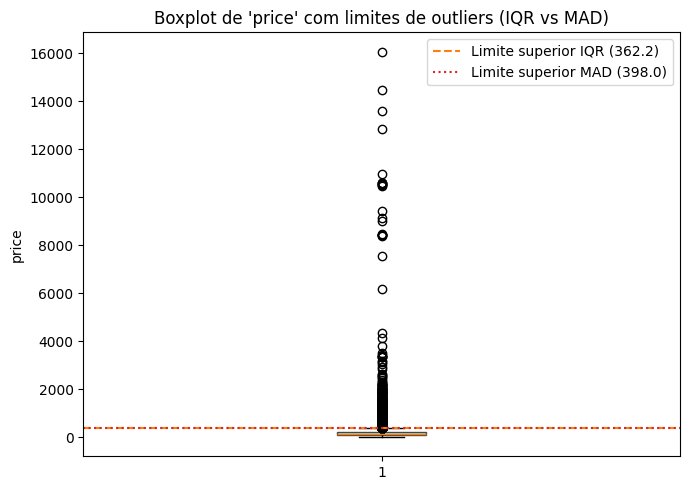

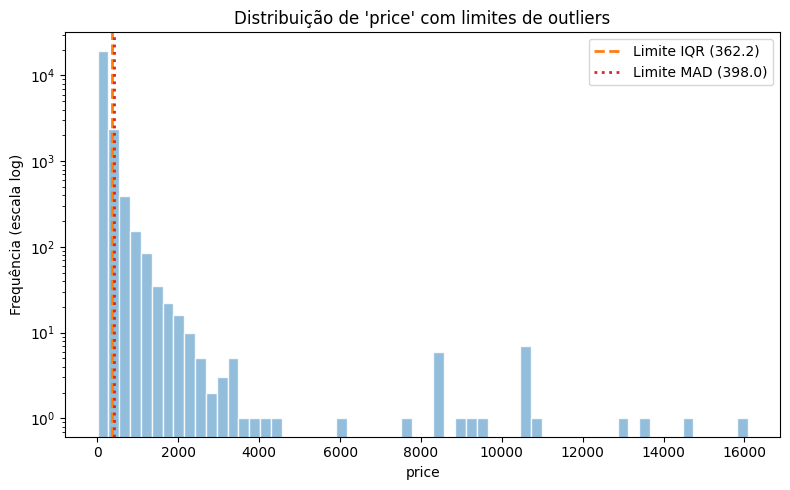

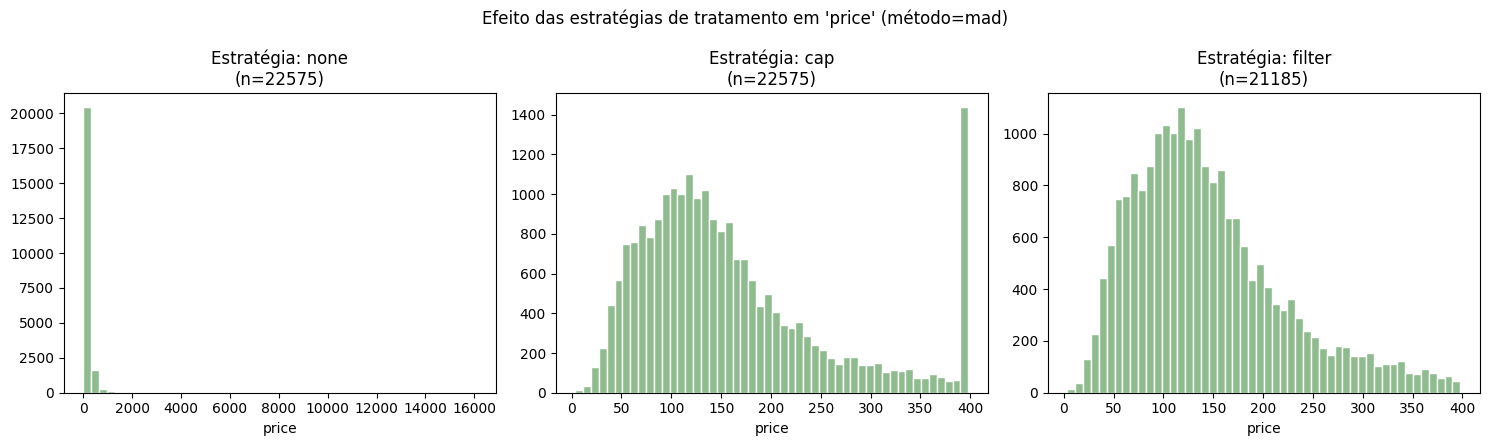


=== Variável: minimum_nights ===
{
  "coluna": "minimum_nights",
  "n_total": 22575,
  "iqr": {
    "n_outliers": 1401,
    "pct_outliers": 6.21,
    "lower_bound": -2.0,
    "upper_bound": 6.0
  },
  "mad": {
    "n_outliers": 1124,
    "pct_outliers": 4.98,
    "lower_bound": -3.189,
    "upper_bound": 7.189
  },
  "concordancia_pct": 80.23
}


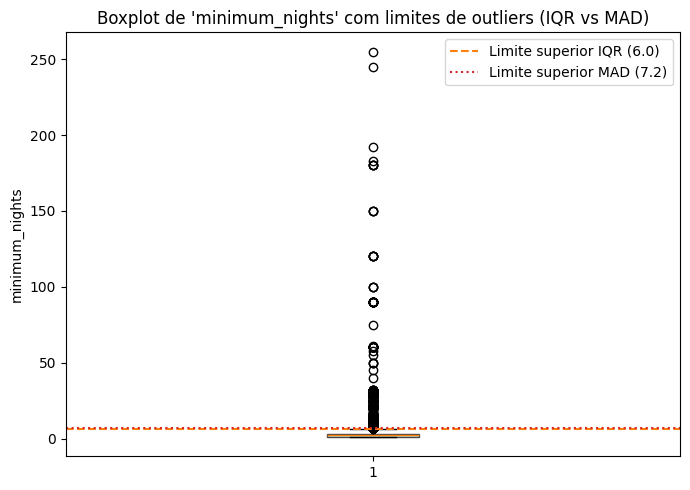

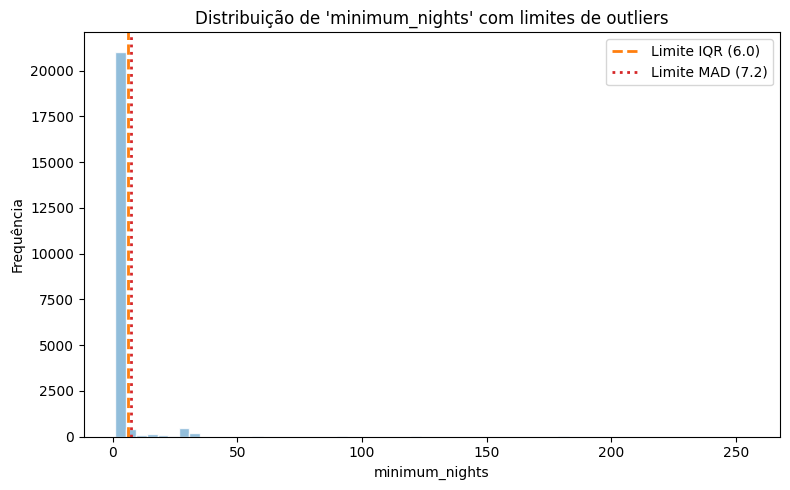

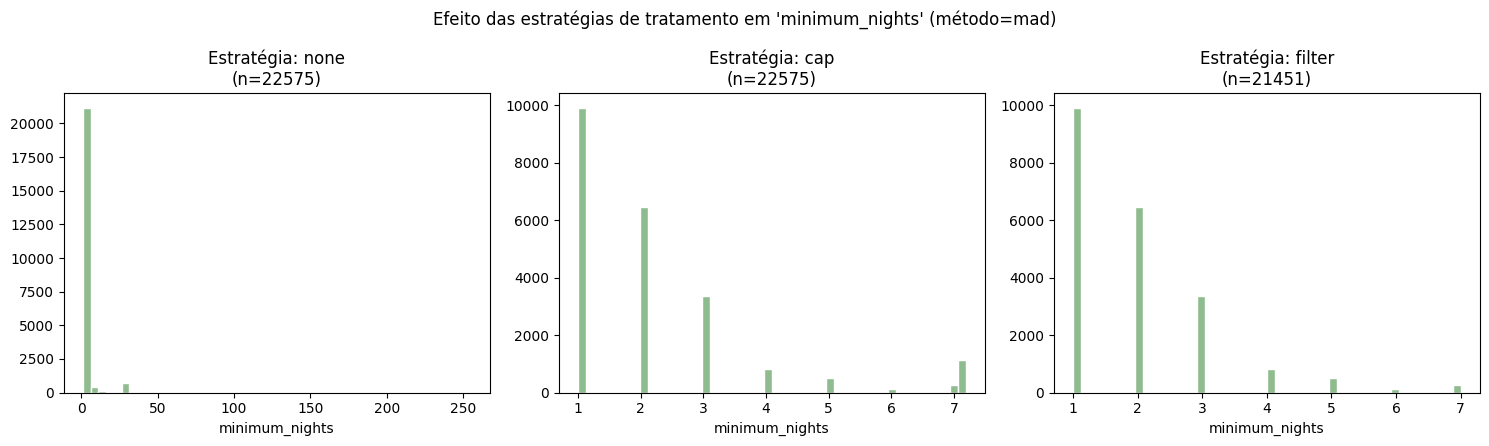


=== Variável: accommodates ===
{
  "coluna": "accommodates",
  "n_total": 22575,
  "iqr": {
    "n_outliers": 1640,
    "pct_outliers": 7.26,
    "lower_bound": -1.0,
    "upper_bound": 7.0
  },
  "mad": {
    "n_outliers": 179,
    "pct_outliers": 0.79,
    "lower_bound": -6.378,
    "upper_bound": 14.378
  },
  "concordancia_pct": 10.91
}


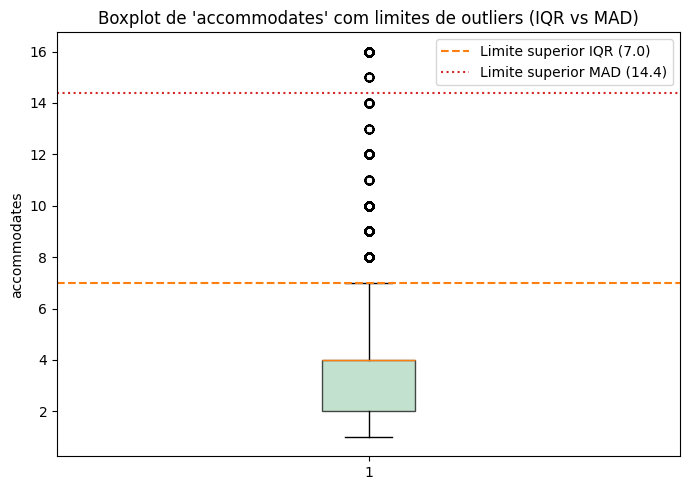

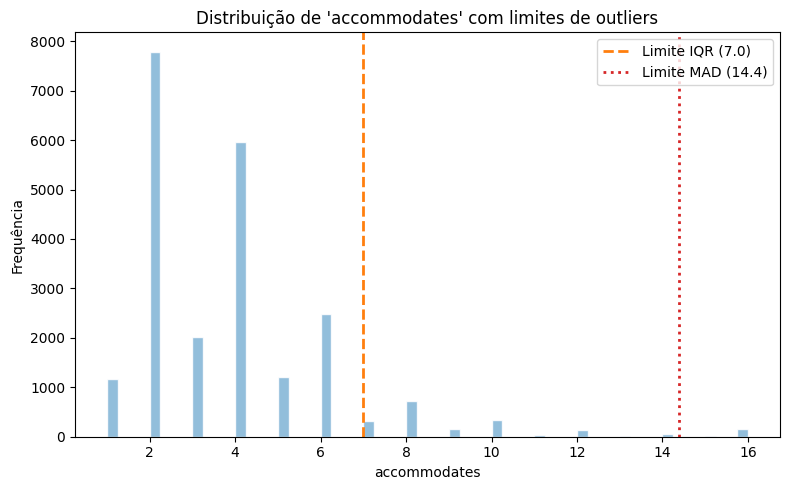

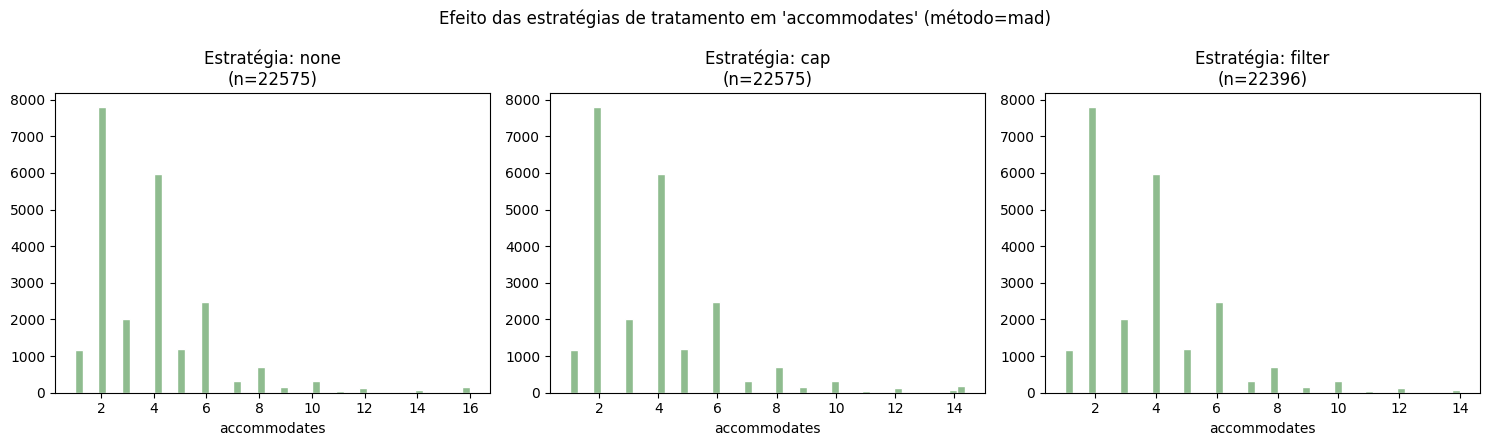

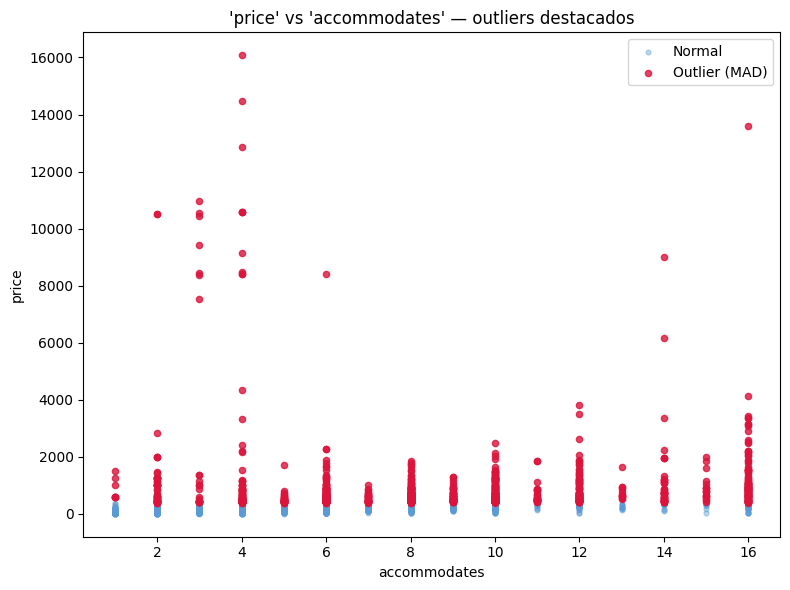

In [17]:
target_cols = ["price", "minimum_nights", "accommodates"]

plot_missingness_matrix(df)

resumo_geral = {}
for col in target_cols:
    if col not in df.columns:
        print(f"[aviso] coluna '{col}' não encontrada, a saltar.")
        continue

    print(f"\n=== Variável: {col} ===")
    resumo = summarize_outliers(df, col)
    resumo_geral[col] = resumo
    print(json.dumps(resumo, indent=2, ensure_ascii=False))

    plot_boxplot_comparison(df, col)
    plot_histogram_with_bounds(df, col, log_scale=(col == "price"))
    plot_strategy_comparison(df, col, method="mad")

if "price" in df.columns and "accommodates" in df.columns:
    plot_scatter_outliers(df, "accommodates", "price")

### 6.4 Guardar as 3 estratégias tratadas em CSV

In [18]:
def save_outlier_strategies(df, target_cols, outdir="outlier_versions",
                             method="mad", prefix="listings"):
    """
    Aplica as 3 estratégias (none, cap, filter) sobre as colunas em target_cols
    e guarda cada versão completa do dataframe num CSV separado.

    Para 'filter' com várias colunas: aplica sequencialmente, coluna a coluna
    (cada remoção usa os quantis/mediana recalculados no dataframe já filtrado
    pela coluna anterior). É uma abordagem conservadora — remove ligeiramente
    mais do que uma deteção simultânea de todas as colunas de uma vez, mas
    evita reintroduzir outliers de uma coluna ao tratar a seguinte.
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    resultados = {}

    for strategy in ["none", "cap", "filter"]:
        df_strat = df.copy()
        for col in target_cols:
            if col not in df_strat.columns:
                print(f"[aviso] coluna '{col}' não encontrada, a saltar em '{strategy}'.")
                continue
            df_strat = apply_strategy(df_strat, col, strategy=strategy, method=method)

        filename = outdir / f"{prefix}_{strategy}.csv"
        df_strat.to_csv(filename, index=False)

        resultados[strategy] = {
            "ficheiro": str(filename),
            "n_linhas": len(df_strat),
            "n_linhas_removidas": len(df) - len(df_strat),
        }
        print(f"[{strategy}] guardado em {filename}  "
              f"(n={len(df_strat)}, removidas={len(df) - len(df_strat)})")

    return resultados


target_cols = ["price", "minimum_nights", "accommodates"]
resultados = save_outlier_strategies(df, target_cols, outdir="outlier_versions", method="mad")

[none] guardado em outlier_versions\listings_none.csv  (n=22575, removidas=0)
[cap] guardado em outlier_versions\listings_cap.csv  (n=22575, removidas=0)
[filter] guardado em outlier_versions\listings_filter.csv  (n=19717, removidas=2858)


## 7. Preparação de Features

Usamos `prepare_features` (em `src/`) para classificar automaticamente cada coluna (contínua / binária / categórica / excluir) e aplicar o tratamento final (t/f → 0/1, one-hot, exclusão de colunas redundantes e de *leakage*).

Não há seleção de variáveis: o modelo usa **todas** as features que saem do `prepare_features`.

Feito aqui sobre `listings_filter.csv` como referência; o mesmo `prepare_features` é reaplicado por estratégia na secção de treino.

In [19]:
from prepare_features import prepare_features, combine_host_time_features, KNOWN_REDUNDANT_COLS

target_col = "price"
outlier_dir = Path("outlier_versions")

df_raw = pd.read_csv(outlier_dir / "listings_filter.csv")
df_raw = combine_host_time_features(df_raw)

df_final, feature_cols, scale_cols = prepare_features(
    df_raw, target_col=target_col,
    exclude_cols=KNOWN_REDUNDANT_COLS,
    force_continuous=["minimum_nights"],
)
df_final = df_final.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

print(f"{len(feature_cols)} features ({len(scale_cols)} contínuas), sem seleção de features")

coluna                              ação                           nota
------------------------------------------------------------------------------------------
host_location                       excluída                       lista de exclusão
host_is_superhost                   passthrough (t/f->0/1)         
host_listings_count                 scale_cols (contínua)          105 valores únicos
host_has_profile_pic                passthrough (t/f->0/1)         
host_identity_verified              passthrough (t/f->0/1)         
neighbourhood_cleansed              excluída                       lista de exclusão
neighbourhood_group_cleansed        one-hot (15 cols)              16 categorias
latitude                            scale_cols (contínua)          12253 valores únicos
longitude                           scale_cols (contínua)          13204 valores únicos
property_type                       excluída                       alta cardinalidade (85 categorias)
room_type         

## 8. Treino dos Modelos (Gradient Descent)

Percorre as 3 estratégias de outliers × graus polinomiais 1 a 4 (linear a quártico), numa única divisão 70% treino / 15% validação / 15% teste (sem k-fold). Sem regularização L2 (`l2_lambda=0.0`), `learning_rate=0.001`, `n_epochs=1000`. Guarda os pesos e o histórico de loss de cada combinação (estratégia × grau) em `Modelos_treinados/`.

In [ ]:
from linear_regression import run_experiment, save_experiment
from pathlib import Path

modelos_dir = Path("Modelos_treinados")

outlier_strategies = ["none", "cap", "filter"]
degrees = [1, 2, 3, 4]

todos_resultados = []

for strategy in outlier_strategies:
    df_raw_strat = pd.read_csv(outlier_dir / f"listings_{strategy}.csv")
    df_raw_strat = combine_host_time_features(df_raw_strat)
    df_final_strat, feature_cols_strat, scale_cols_strat = prepare_features(
        df_raw_strat, target_col=target_col, exclude_cols=KNOWN_REDUNDANT_COLS,
        force_continuous=["minimum_nights"], verbose=False,
    )
    df_final_strat = df_final_strat.dropna(subset=feature_cols_strat + [target_col]).reset_index(drop=True)

    for degree in degrees:
        print(f"[{strategy}] grau={degree}...")
        resultado = run_experiment(
            df_final_strat, feature_cols_strat, target_col, degree=degree,
            scale_cols=scale_cols_strat, test_size=0.15, val_size=0.15,
            learning_rate=0.001, n_epochs=1000, l2_lambda=0.0,
            verbose=False, plot=False,
        )
        linha = {
            "outlier_strategy": strategy, "degree": degree,
            "n_features_final": resultado["n_features_final"],
        }
        for split in ("train", "val", "test"):
            for metrica, valor in resultado["metrics"][split].items():
                linha[f"{metrica}_{split}"] = valor
        todos_resultados.append(linha)

        caminho_modelo = save_experiment(
            resultado, modelos_dir / f"{strategy}_grau{degree}.joblib"
        )
        print(f"  -> pesos e histórico guardados em: {caminho_modelo}")

df_todos = pd.DataFrame(todos_resultados)
df_todos.to_csv("gd_results_single_split.csv", index=False)
print(f"Resultados: {len(df_todos)} linhas")

[none] grau=1...
  -> pesos e histórico guardados em: Modelos_treinados\none_grau1.joblib
[none] grau=2...
  -> pesos e histórico guardados em: Modelos_treinados\none_grau2.joblib
[none] grau=3...


In [ ]:
df_todos.head(20)

## 9. Comparação com Baseline

Verifica se o modelo bate um baseline ingénuo (prever sempre a mediana), por estratégia de outliers.

In [ ]:
for strategy in outlier_strategies:
    df_raw_strat = pd.read_csv(outlier_dir / f"listings_{strategy}.csv")
    mediana = df_raw_strat['price'].median()
    media = df_raw_strat['price'].mean()
    print(f"[{strategy}] média={media:.2f}  mediana={mediana:.2f}")

## 10. Avaliação num Dataset Novo (Nova Iorque)

Trata um dataset de uma cidade diferente (Nova Iorque) com a mesma estratégia de outliers (`filter`), e usa-o **inteiro** como conjunto de teste (sem voltar a fazer split) para avaliar os modelos já treinados com os dados de Lisboa (secção 8, estratégia `filter`, graus 1 a 4).

Como o one-hot encoding do novo dataset pode gerar colunas diferentes (bairros/boroughs distintos de Nova Iorque), `evaluate_saved_model` realinha as colunas do dataset novo com as que foram usadas no treino original (colunas em falta ficam a 0, colunas a mais são ignoradas) e reaplica (sem refazer fit) o `poly`/`scaler` guardados.

**Aviso**: espera-se que os resultados sejam maus. `latitude`/`longitude` são features contínuas escaladas com a média/desvio-padrão de Lisboa — as coordenadas de Nova Iorque ficam a centenas de desvios-padrão de distância dessa escala, e ao serem expandidas polinomialmente (graus 2-4) explodem para valores absurdos. Isto não é um bug: é o resultado esperado de aplicar um modelo treinado numa cidade a coordenadas geográficas completamente fora da distribuição de treino.

In [ ]:
from linear_regression import load_experiment, evaluate_saved_model
from data_preparation import preparar_dados, guardar_dados_tratados

caminho_novo = "nova_york.csv.gz"

# usa o scale_cols do modelo de grau 1 como referência: garante que colunas
# como bathrooms/bedrooms/beds ficam contínuas no dataset novo mesmo que,
# sendo uma amostra pequena, tenham poucos valores únicos (o que a
# heurística automática do prepare_features trataria como discreta/one-hot)
payload_referencia = load_experiment(Path("Modelos_treinados") / "filter_grau1.joblib")

df_novo, feature_cols_novo, scale_cols_novo = preparar_dados(
    caminho_novo, tipo="filter", force_continuous=payload_referencia["scale_cols"]
)
guardar_dados_tratados(df_novo, caminho_novo, "filter")

resultados_novo = []
for degree in [1, 2, 3, 4]:
    payload = load_experiment(Path("Modelos_treinados") / f"filter_grau{degree}.joblib")
    metricas = evaluate_saved_model(payload, df_novo, target_col=target_col)
    resultados_novo.append({"degree": degree, **metricas})
    print(f"[filter] grau={degree}: mse={metricas['mse']:.2f}  mae={metricas['mae']:.2f}  "
          f"rmse={metricas['rmse']:.2f}  r2={metricas['r2']:.4f}")

df_resultados_novo = pd.DataFrame(resultados_novo)
df_resultados_novo.to_csv("gd_resultados_nova_york.csv", index=False)
df_resultados_novo

## 11. Comparação entre Cidades — Distância ao Centro em vez de Lat/Lon (Opção B)

Na secção 10 vimos que aplicar o modelo de Lisboa (treinado com `latitude`/`longitude` absolutas) a Nova Iorque dá métricas absurdas — as coordenadas de Nova Iorque ficam a centenas de desvios-padrão da distribuição de Lisboa usada pelo `scaler`, e explodem ao serem expandidas polinomialmente.

Aqui substituímos `latitude`/`longitude` por **`dist_centro_km`**: a distância (Haversine) de cada listagem ao centro geográfico do seu PRÓPRIO dataset. `0 km` passa a significar sempre "no centro da cidade em causa", tornando a feature comparável entre cidades — ao contrário de coordenadas absolutas, que não têm esse significado partilhado.

### 11.1 Baseline — inferência sem este tratamento (lat/lon absolutos)

Resultados já obtidos na secção 10, com os modelos treinados com `latitude`/`longitude` absolutas, avaliados no dataset completo de Nova Iorque.

In [ ]:
df_baseline_latlon = pd.read_csv("gd_resultados_nova_york.csv")
df_baseline_latlon

### 11.2 Treino em Lisboa com `dist_centro_km` (substitui lat/lon)

Mesma estratégia de outliers (`filter`), mesmos hiperparâmetros da secção 8 (sem L2, `learning_rate=0.001`, `n_epochs=1000`, split único 70/15/15) — a única diferença é a feature geográfica.

In [ ]:
from prepare_features import adicionar_distancia_ao_centro

df_raw_dc = pd.read_csv(outlier_dir / "listings_filter.csv")
df_raw_dc = combine_host_time_features(df_raw_dc)
df_raw_dc, centro_lisboa = adicionar_distancia_ao_centro(df_raw_dc)
print(f"Centro geográfico de Lisboa usado: {centro_lisboa}")

df_final_dc, feature_cols_dc, scale_cols_dc = prepare_features(
    df_raw_dc, target_col=target_col, exclude_cols=KNOWN_REDUNDANT_COLS,
    force_continuous=["minimum_nights"], verbose=False,
)
df_final_dc = df_final_dc.dropna(subset=feature_cols_dc + [target_col]).reset_index(drop=True)

resultados_distcentro = []
for degree in [1, 2, 3, 4]:
    print(f"[filter+distcentro] grau={degree}...")
    resultado = run_experiment(
        df_final_dc, feature_cols_dc, target_col, degree=degree,
        scale_cols=scale_cols_dc, test_size=0.15, val_size=0.15,
        learning_rate=0.001, n_epochs=1000, l2_lambda=0.0,
        verbose=False, plot=False,
    )
    save_experiment(resultado, modelos_dir / f"filter_distcentro_grau{degree}.joblib")
    linha = {"degree": degree, "n_features_final": resultado["n_features_final"]}
    for split in ("train", "val", "test"):
        for metrica, valor in resultado["metrics"][split].items():
            linha[f"{metrica}_{split}"] = valor
    resultados_distcentro.append(linha)

df_lisboa_distcentro = pd.DataFrame(resultados_distcentro)
df_lisboa_distcentro.to_csv("gd_results_lisboa_distcentro.csv", index=False)
df_lisboa_distcentro

### 11.3 Avaliação em Nova Iorque com `dist_centro_km`

Trata Nova Iorque com a mesma transformação (distância ao SEU PRÓPRIO centro) e usa o dataset inteiro como teste dos modelos treinados em 11.2. `force_continuous` usa o `scale_cols` do modelo de referência para evitar que colunas como bathrooms/bedrooms/beds sejam mal classificadas devido à amostra pequena de Nova Iorque (ver secção 10).

In [ ]:
payload_ref_dc = load_experiment(modelos_dir / "filter_distcentro_grau1.joblib")

df_novo_dc, feature_cols_novo_dc, scale_cols_novo_dc = preparar_dados(
    caminho_novo, tipo="filter",
    force_continuous=payload_ref_dc["scale_cols"],
    usar_distancia_centro=True,
)
guardar_dados_tratados(df_novo_dc, caminho_novo, "filter_distcentro")

resultados_novo_dc = []
for degree in [1, 2, 3, 4]:
    payload_dc = load_experiment(modelos_dir / f"filter_distcentro_grau{degree}.joblib")
    metricas_dc = evaluate_saved_model(payload_dc, df_novo_dc, target_col=target_col)
    resultados_novo_dc.append({"degree": degree, **metricas_dc})
    print(f"[filter+distcentro] grau={degree}: mae={metricas_dc['mae']:.2f}  "
          f"rmse={metricas_dc['rmse']:.2f}  r2={metricas_dc['r2']:.4f}")

df_ny_distcentro = pd.DataFrame(resultados_novo_dc)
df_ny_distcentro.to_csv("gd_resultados_nova_york_distcentro.csv", index=False)
df_ny_distcentro

### 11.4 Comparação final: lat/lon absolutos vs. distância ao centro

In [ ]:
comparacao = df_baseline_latlon[["degree", "mae", "rmse", "r2"]].rename(
    columns={"mae": "mae_latlon", "rmse": "rmse_latlon", "r2": "r2_latlon"}
).merge(
    df_ny_distcentro[["degree", "mae", "rmse", "r2"]].rename(
        columns={"mae": "mae_distcentro", "rmse": "rmse_distcentro", "r2": "r2_distcentro"}
    ),
    on="degree",
)
comparacao

## 12. Validação Cruzada 5-Fold — Graus 1 a 4, por Estratégia de Outliers

A secção 8 usou um único split 70/15/15, o que torna as métricas dependentes de *que* linhas calharam no teste. Aqui usamos **5-fold cross-validation** (`run_kfold_experiment`, `KFold(shuffle=True, random_state=42)`): cada linha é usada exatamente uma vez como validação, e reportamos a **média ± desvio-padrão** das métricas de validação nos 5 folds.

Mesmos hiperparâmetros da secção 8 (sem L2, `learning_rate=0.001`, `n_epochs=1000`), graus 1 a 4. Cada estratégia de outliers é corrida separadamente (12.1 `none`, 12.2 `cap`, 12.3 `filter`) e comparada em 12.4.

**Nota:** o grau 4 gera ~15 000–17 500 features; cada fold demora vários minutos e precisa de ~6–9 GB de RAM.

In [2]:
from linear_regression import run_kfold_experiment
from prepare_features import prepare_features, combine_host_time_features, KNOWN_REDUNDANT_COLS

target_col = "price"
outlier_dir = Path("outlier_versions")
outlier_strategies = ["none", "cap", "filter"]
degrees = [1, 2, 3, 4]

KFOLD_CONFIG = dict(n_splits=5, learning_rate=0.001, n_epochs=1000, l2_lambda=0.0,
                    random_state=42, return_history=False)


def carregar_estrategia(strategy):
    """Lê o CSV da estratégia de outliers e aplica o mesmo prepare_features da secção 8."""
    df_raw_strat = pd.read_csv(outlier_dir / f"listings_{strategy}.csv")
    df_raw_strat = combine_host_time_features(df_raw_strat)
    df_final_strat, feature_cols_strat, scale_cols_strat = prepare_features(
        df_raw_strat, target_col=target_col, exclude_cols=KNOWN_REDUNDANT_COLS,
        force_continuous=["minimum_nights"], verbose=False,
    )
    df_final_strat = df_final_strat.dropna(subset=feature_cols_strat + [target_col]).reset_index(drop=True)
    return df_final_strat, feature_cols_strat, scale_cols_strat


def correr_kfold_estrategia(strategy):
    """5-fold CV em todos os graus para UMA estratégia; devolve uma linha por fold."""
    df_s, feats_s, scale_s = carregar_estrategia(strategy)
    linhas = []
    for degree in degrees:
        folds = run_kfold_experiment(df_s, feats_s, target_col, degree=degree,
                                     scale_cols=scale_s, **KFOLD_CONFIG)
        for f in folds:
            f["outlier_strategy"] = strategy
        linhas.extend(folds)
        r2 = [f["r2_val"] for f in folds]
        mae = [f["mae_val"] for f in folds]
        print(f"[{strategy}] grau={degree}: R2 val = {np.mean(r2):.4f} ± {np.std(r2):.4f} | "
              f"MAE val = {np.mean(mae):.2f} ± {np.std(mae):.2f} | "
              f"folds divergidos = {sum(f['diverged'] for f in folds)}")
    return pd.DataFrame(linhas)


def resumo_kfold(df_folds):
    """Média e desvio-padrão das métricas por (estratégia, grau)."""
    return (df_folds.groupby(["outlier_strategy", "degree"], sort=False)
            [["mae_train", "rmse_train", "r2_train", "mae_val", "rmse_val", "r2_val"]]
            .agg(["mean", "std"]).round(4))

### 12.1 Estratégia `none` (sem tratamento de outliers)

In [3]:
df_kfold_none = correr_kfold_estrategia("none")
resumo_kfold(df_kfold_none)

[none] grau=1: R2 val = 0.1414 ± 0.0480 | MAE val = 86.28 ± 3.62 | folds divergidos = 0


[none] grau=2: R2 val = 0.1688 ± 0.0563 | MAE val = 81.34 ± 3.41 | folds divergidos = 0


[none] grau=3: R2 val = 0.1881 ± 0.0679 | MAE val = 79.56 ± 3.63 | folds divergidos = 0


/tmp/claude-1000/-home-andrputoi-PycharmProjects-Machine-Learning-1/96544230-05ec-404a-a5a4-20ed6d2e98aa/scratchpad/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


[DIVERGÊNCIA] Loss tornou-se NaN/Inf na época 177.


...

/tmp/claude-1000/-home-andrputoi-PycharmProjects-Machine-Learning-1/96544230-05ec-404a-a5a4-20ed6d2e98aa/scratchpad/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


[DIVERGÊNCIA] Loss tornou-se NaN/Inf na época 176.


/tmp/claude-1000/-home-andrputoi-PycharmProjects-Machine-Learning-1/96544230-05ec-404a-a5a4-20ed6d2e98aa/scratchpad/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


[DIVERGÊNCIA] Loss tornou-se NaN/Inf na época 177.
[none] grau=4: R2 val = -0.8742 ± 0.2249 | MAE val = 282.79 ± 11.70 | folds divergidos = 5


mae_train         rmse_train          r2_train  \
                             mean     std       mean      std     mean   
outlier_strategy degree                                                  
none             1        86.2135  1.8733   353.4727  18.6407   0.1308   
                 2        80.9164  1.8635   345.6666  17.9656   0.1686   
                 3        77.9699  2.0597   335.9803  16.9406   0.2143   
                 4       282.2092  6.3484   504.9968   8.6673  -0.7809   

                                  mae_val           rmse_val           r2_val  \
                            std      mean      std      mean      std    mean   
outlier_strategy degree                                                         
none             1       0.0104   86.2837   4.0440  347.6554  76.6023  0.1414   
                 2       0.0144   81.3438   3.8077  342.0099  75.3510  0.1688   
                 3       0.0220   79.5554   4.0601  338.0599  75.3604  0.1881   
                 4       0.1220  282.7875  13.0805  507.1874  82.2332 -0.8742   

                                 
                            std  
outlier_strategy degree          
none             1       0.0537  
                 2       0.0629  
                 3       0.0759  
                 4       0.2514

### 12.2 Estratégia `cap` (winsorization com limites MAD)

In [4]:
df_kfold_cap = correr_kfold_estrategia("cap")
resumo_kfold(df_kfold_cap)

[cap] grau=1: R2 val = 0.4882 ± 0.0169 | MAE val = 50.13 ± 0.47 | folds divergidos = 0


[cap] grau=2: R2 val = 0.5420 ± 0.0135 | MAE val = 47.48 ± 0.51 | folds divergidos = 0


[cap] grau=3: R2 val = 0.5593 ± 0.0580 | MAE val = 45.33 ± 0.55 | folds divergidos = 0


/tmp/claude-1000/-home-andrputoi-PycharmProjects-Machine-Learning-1/96544230-05ec-404a-a5a4-20ed6d2e98aa/scratchpad/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


[DIVERGÊNCIA] Loss tornou-se NaN/Inf na época 172.


...

/tmp/claude-1000/-home-andrputoi-PycharmProjects-Machine-Learning-1/96544230-05ec-404a-a5a4-20ed6d2e98aa/scratchpad/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


[DIVERGÊNCIA] Loss tornou-se NaN/Inf na época 171.


/tmp/claude-1000/-home-andrputoi-PycharmProjects-Machine-Learning-1/96544230-05ec-404a-a5a4-20ed6d2e98aa/scratchpad/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


[DIVERGÊNCIA] Loss tornou-se NaN/Inf na época 172.
[cap] grau=4: R2 val = -8.4500 ± 1.3065 | MAE val = 227.82 ± 5.19 | folds divergidos = 5


mae_train         rmse_train         r2_train          \
                             mean     std       mean     std     mean     std   
outlier_strategy degree                                                         
cap              1        50.0616  0.2272    68.5839  0.3035   0.4907  0.0041   
                 2        47.3105  0.2107    64.6750  0.3134   0.5471  0.0041   
                 3        44.8025  0.2214    61.3746  0.3163   0.5922  0.0037   
                 4       227.7303  3.6077   292.0457  4.9644  -8.2354  0.2867   

                          mae_val          rmse_val           r2_val          
                             mean     std      mean      std    mean     std  
outlier_strategy degree                                                       
cap              1        50.1255  0.5281   68.7314   1.3327  0.4882  0.0189  
                 2        47.4766  0.5745   65.0175   1.2482  0.5420  0.0151  
                 3        45.3279  0.6196   63.6422   4.2105  0.5593  0.0648  
                 4       227.8243  5.7972  294.6401  20.5247 -8.4500  1.4607

### 12.3 Estratégia `filter` (remoção das linhas com outliers)

In [5]:
df_kfold_filter = correr_kfold_estrategia("filter")
resumo_kfold(df_kfold_filter)

[filter] grau=1: R2 val = 0.3464 ± 0.0183 | MAE val = 44.59 ± 0.38 | folds divergidos = 0


[filter] grau=2: R2 val = 0.4129 ± 0.0127 | MAE val = 42.58 ± 0.40 | folds divergidos = 0


[filter] grau=3: R2 val = 0.3886 ± 0.1374 | MAE val = 40.94 ± 0.44 | folds divergidos = 0


/tmp/claude-1000/-home-andrputoi-PycharmProjects-Machine-Learning-1/96544230-05ec-404a-a5a4-20ed6d2e98aa/scratchpad/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


[DIVERGÊNCIA] Loss tornou-se NaN/Inf na época 188.


...

/tmp/claude-1000/-home-andrputoi-PycharmProjects-Machine-Learning-1/96544230-05ec-404a-a5a4-20ed6d2e98aa/scratchpad/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


[DIVERGÊNCIA] Loss tornou-se NaN/Inf na época 188.


[DIVERGÊNCIA] Loss tornou-se NaN/Inf na época 188.
[filter] grau=4: R2 val = -5.5752 ± 0.2593 | MAE val = 161.31 ± 2.17 | folds divergidos = 5


/tmp/claude-1000/-home-andrputoi-PycharmProjects-Machine-Learning-1/96544230-05ec-404a-a5a4-20ed6d2e98aa/scratchpad/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


mae_train         rmse_train         r2_train          \
                             mean     std       mean     std     mean     std   
outlier_strategy degree                                                         
filter           1        44.5407  0.0814    60.1790  0.1862   0.3505  0.0049   
                 2        42.3992  0.0824    56.6617  0.1962   0.4242  0.0029   
                 3        40.4019  0.1349    54.2037  0.2374   0.4731  0.0035   
                 4       161.1825  0.9712   190.3749  1.1219  -5.5000  0.0475   

                          mae_val          rmse_val          r2_val          
                             mean     std      mean     std    mean     std  
outlier_strategy degree                                                      
filter           1        44.5894  0.4237   60.3459  0.8175  0.3464  0.0204  
                 2        42.5776  0.4505   57.1982  0.7360  0.4129  0.0142  
                 3        40.9386  0.4906   58.0299  6.5595  0.3886  0.1536  
                 4       161.3056  2.4240  191.3821  3.4422 -5.5752  0.2899

### 12.4 Comparação entre estratégias

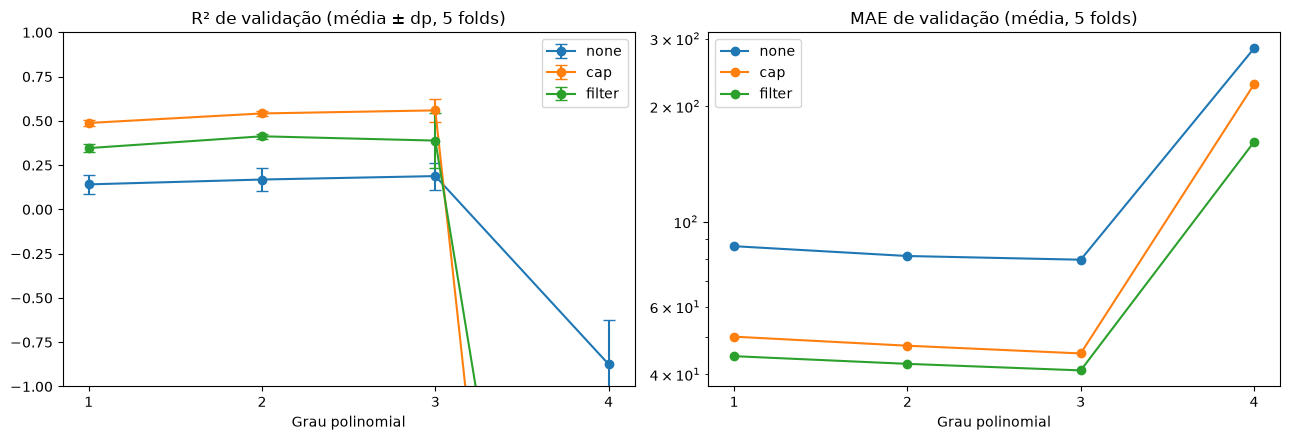

,outlier_strategy,degree,mae_val,rmse_val,r2_val,r2_val_std,r2_train
0,none,1,86.2837,347.6554,0.1414,0.0537,0.1308
1,none,2,81.3438,342.0099,0.1688,0.0629,0.1686
2,none,3,79.5554,338.0599,0.1881,0.0759,0.2143
3,none,4,282.7875,507.1874,-0.8742,0.2514,-0.7809
4,cap,1,50.1255,68.7314,0.4882,0.0189,0.4907
5,cap,2,47.4766,65.0175,0.5420,0.0151,0.5471
6,cap,3,45.3279,63.6422,0.5593,0.0648,0.5922
7,cap,4,227.8243,294.6401,-8.4500,1.4607,-8.2354
8,filter,1,44.5894,60.3459,0.3464,0.0204,0.3505
9,filter,2,42.5776,57.1982,0.4129,0.0142,0.4242


In [6]:
df_kfold = pd.concat([df_kfold_none, df_kfold_cap, df_kfold_filter], ignore_index=True)
df_kfold.to_csv("gd_results_kfold_all_strategies.csv", index=False)

tabela_kfold = (df_kfold.groupby(["outlier_strategy", "degree"], sort=False)
                .agg(mae_val=("mae_val", "mean"), rmse_val=("rmse_val", "mean"),
                     r2_val=("r2_val", "mean"), r2_val_std=("r2_val", "std"),
                     r2_train=("r2_train", "mean"))
                .round(4).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for strategy in outlier_strategies:
    t = tabela_kfold[tabela_kfold["outlier_strategy"] == strategy]
    axes[0].errorbar(t["degree"], t["r2_val"], yerr=t["r2_val_std"], marker="o", capsize=4, label=strategy)
    axes[1].plot(t["degree"], t["mae_val"], marker="o", label=strategy)
axes[0].set_title("R² de validação (média ± dp, 5 folds)")
axes[0].set_ylim(-1, 1)
axes[1].set_title("MAE de validação (média, 5 folds)")
axes[1].set_yscale("log")
for ax in axes:
    ax.set_xlabel("Grau polinomial")
    ax.set_xticks(degrees)
    ax.legend()
plt.tight_layout()
plt.show()

tabela_kfold

### 12.5 Conclusões — 5-fold CV

Média dos 5 folds (validação):

| Estratégia | Grau 1 R² | Grau 2 R² | Grau 3 R² | Grau 4 R² | Melhor MAE |
|---|---|---|---|---|---|
| none | 0.141 | 0.169 | **0.188** | −0.874 | 79.56 (grau 3) |
| cap | 0.488 | 0.542 | **0.559** | −8.450 | 45.33 (grau 3) |
| filter | 0.346 | **0.413** | 0.389 | −5.575 | 40.94 (grau 3) |

- **Confirma a secção 8**: as estratégias com tratamento de outliers são muito melhores que `none` (R² ~0.15 → 0.4–0.56). O RMSE de `none` (~340) é dominado por meia dúzia de preços extremos.
- **`cap` tem o melhor R²**, `filter` o menor erro absoluto (MAE/RMSE). Não são diretamente comparáveis: cada estratégia altera o próprio target (o cap corta os preços altos e o filter remove-os), por isso o conjunto avaliado é diferente.
- **O CV é mais estável que o split único**: o desvio-padrão do R² nos graus 1–2 é baixo (0.014–0.02 em cap/filter), por isso estas diferenças são reais. No grau 3 a variância sobe (dp 0.065 em cap, 0.154 em filter): começa a haver folds onde o modelo generaliza mal — o grau 3 no `filter` fica até **abaixo do grau 2** em média, e o gap treino/validação aumenta (0.47 vs 0.39). **Grau 2–3 é o ponto ideal**; com `filter`, o grau 2 é a escolha mais segura.
- **O grau 4 diverge em 15/15 folds** (todas as estratégias): o gradient descent explode logo nas primeiras épocas e o checkpoint restaurado é o da época 0, daí o R² negativo. Com ~15–17 mil features polinomiais e `learning_rate=0.001`, o passo é demasiado grande para esta matriz mal condicionada — os outliers não tratados nas outras variáveis (ex. `bedrooms`, `maximum_nights`) elevados à 4.ª potência agravam isto. Seria preciso um learning rate muito menor (ou tratar essas variáveis) para o grau 4 sequer convergir.

## 13. Regularização L2 — λ ∈ {0.25, 0.5, 0.75}

Experimentos únicos (mesmo split 70/15/15 com `random_state=42` da secção 8 — as linhas de treino/val/teste são exatamente as mesmas), para cada grau 1 a 4, com a estratégia `filter` (a usada como referência nas secções 7, 10 e 11). Restantes hiperparâmetros iguais: `learning_rate=0.001`, `n_epochs=1000`. A linha λ=0 vem dos resultados da secção 8 (`gd_results_single_split.csv`).

Na implementação (`LinearRegressionGD`), a loss é `MSE + λ·Σw²/n` e o gradiente do termo L2 é `2λ·w/n`, com `n` = nº de linhas de treino.

In [7]:
from linear_regression import run_experiment

l2_lambdas = [0.25, 0.5, 0.75]
df_l2_base, feature_cols_l2, scale_cols_l2 = carregar_estrategia("filter")

resultados_l2 = []
for degree in degrees:
    for lam in l2_lambdas:
        resultado = run_experiment(
            df_l2_base, feature_cols_l2, target_col, degree=degree,
            scale_cols=scale_cols_l2, test_size=0.15, val_size=0.15,
            learning_rate=0.001, n_epochs=1000, l2_lambda=lam,
            verbose=False, plot=False,
        )
        linha = {"degree": degree, "l2_lambda": lam,
                 "n_features_final": resultado["n_features_final"],
                 "norma_pesos": float(np.linalg.norm(resultado["model"].weights_))}
        for split in ("train", "val", "test"):
            for metrica, valor in resultado["metrics"][split].items():
                linha[f"{metrica}_{split}"] = valor
        resultados_l2.append(linha)
        print(f"[filter] grau={degree} λ={lam}: R2 val={linha['r2_val']:.4f}  "
              f"R2 test={linha['r2_test']:.4f}  MAE test={linha['mae_test']:.2f}  "
              f"||w||={linha['norma_pesos']:.2f}")

n_treino = len(df_l2_base) - int(len(df_l2_base) * 0.15) * 2
print(f"\nn (treino) = {n_treino} -> força efetiva no gradiente 2λ/n: "
      + ", ".join(f"λ={lam}: {2 * lam / n_treino:.2e}" for lam in l2_lambdas))

df_l2 = pd.DataFrame(resultados_l2)
df_l2.to_csv("gd_results_l2.csv", index=False)

[filter] grau=1 λ=0.25: R2 val=0.3797  R2 test=0.3231  MAE test=44.88  ||w||=69.66


[filter] grau=1 λ=0.5: R2 val=0.3797  R2 test=0.3231  MAE test=44.88  ||w||=69.66


[filter] grau=1 λ=0.75: R2 val=0.3797  R2 test=0.3231  MAE test=44.88  ||w||=69.66


[filter] grau=2 λ=0.25: R2 val=0.4373  R2 test=0.4138  MAE test=42.49  ||w||=67.18


[filter] grau=2 λ=0.5: R2 val=0.4373  R2 test=0.4138  MAE test=42.49  ||w||=67.18


...

[DIVERGÊNCIA] Loss tornou-se NaN/Inf na época 187.
[filter] grau=4 λ=0.25: R2 val=-5.2806  R2 test=-5.6471  MAE test=161.92  ||w||=2.83


/tmp/claude-1000/-home-andrputoi-PycharmProjects-Machine-Learning-1/96544230-05ec-404a-a5a4-20ed6d2e98aa/scratchpad/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


[DIVERGÊNCIA] Loss tornou-se NaN/Inf na época 187.
[filter] grau=4 λ=0.5: R2 val=-5.2806  R2 test=-5.6471  MAE test=161.92  ||w||=2.83


[DIVERGÊNCIA] Loss tornou-se NaN/Inf na época 187.
[filter] grau=4 λ=0.75: R2 val=-5.2806  R2 test=-5.6471  MAE test=161.92  ||w||=2.83

n (treino) = 13803 -> força efetiva no gradiente 2λ/n: λ=0.25: 3.62e-05, λ=0.5: 7.24e-05, λ=0.75: 1.09e-04


/tmp/claude-1000/-home-andrputoi-PycharmProjects-Machine-Learning-1/96544230-05ec-404a-a5a4-20ed6d2e98aa/scratchpad/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


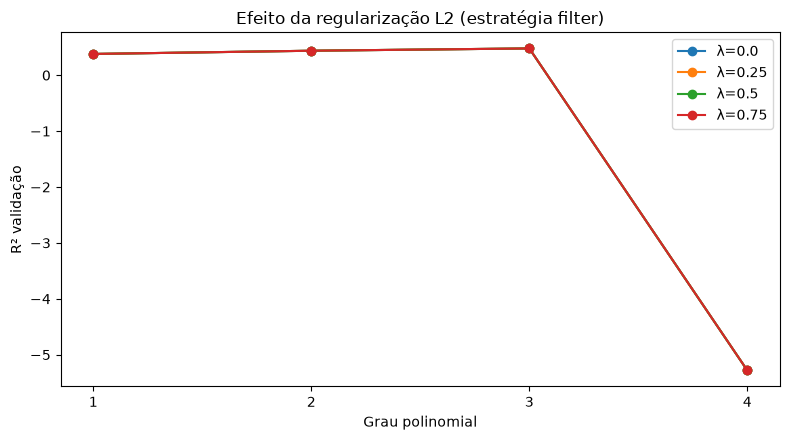

,degree,l2_lambda,r2_train,r2_val,r2_test,mae_val,mae_test,rmse_test
0,1,0.00,0.3488,0.3797,0.3231,43.9614,44.8776,60.7108
1,1,0.25,0.3488,0.3797,0.3231,43.9614,44.8776,60.7108
2,1,0.50,0.3488,0.3797,0.3231,43.9614,44.8776,60.7109
3,1,0.75,0.3488,0.3797,0.3231,43.9614,44.8776,60.7109
4,2,0.00,0.4207,0.4373,0.4138,41.7338,42.4883,56.4971
5,2,0.25,0.4207,0.4373,0.4138,41.7338,42.4883,56.4972
6,2,0.50,0.4207,0.4373,0.4138,41.7337,42.4883,56.4972
7,2,0.75,0.4207,0.4373,0.4138,41.7337,42.4883,56.4973
8,3,0.00,0.4694,0.4785,0.4554,40.0520,40.6504,54.4560
9,3,0.25,0.4694,0.4785,0.4554,40.0520,40.6504,54.4560


In [8]:
# Junta o λ=0 (secção 8, mesma estratégia e mesmo split) para comparação
df_l0 = pd.read_csv("gd_results_single_split.csv")
df_l0 = df_l0[df_l0["outlier_strategy"] == "filter"].drop(columns="outlier_strategy").assign(l2_lambda=0.0)

colunas = ["degree", "l2_lambda", "r2_train", "r2_val", "r2_test", "mae_val", "mae_test", "rmse_test"]
tabela_l2 = (pd.concat([df_l0, df_l2], ignore_index=True)[colunas]
             .sort_values(["degree", "l2_lambda"]).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 4.5))
for lam, t in tabela_l2.groupby("l2_lambda"):
    ax.plot(t["degree"], t["r2_val"], marker="o", label=f"λ={lam}")
ax.set_xlabel("Grau polinomial")
ax.set_ylabel("R² validação")
ax.set_xticks(degrees)
ax.set_title("Efeito da regularização L2 (estratégia filter)")
ax.legend()
plt.tight_layout()
plt.show()

tabela_l2.round(4)

### 13.1 Conclusões — L2

- **λ ∈ {0.25, 0.5, 0.75} não tem efeito prático**: R², MAE e RMSE são iguais a λ=0 até à 4.ª casa decimal em todos os graus. A norma dos pesos só desce na 4.ª casa (ex. grau 1: 69.661 → 69.659).
- **Porquê**: na implementação o termo L2 está dividido por `n` — o gradiente é `2λ·w/n`. Com n ≈ 13 800 linhas de treino, a força efetiva é ~2·10⁻⁵ a 1·10⁻⁴ por época; ao fim de 1000 épocas com `learning_rate=0.001`, encolhe os pesos em menos de 0.01%. Para ter efeito visível, λ teria de ser da ordem de centenas a milhares (ex. 100, 1000, 10 000).
- **Também não salva o grau 4**: o problema aí é divergência do gradient descent (passo demasiado grande), não overfitting — e a L2 não muda o passo nem o condicionamento da matriz.
- **Além disso, os graus 1–3 não sofrem de overfitting forte** no split único (R² treino ≈ R² val), por isso mesmo um L2 mais forte traria pouco ganho. Onde a regularização poderia ajudar é no grau 3, cuja variância entre folds sobe na secção 12.

## 14. Classificação — Preço em 4 Categorias (Regressão Logística)

Em vez de prever o preço exato, transformamos o problema em **classificação multiclasse**. A nova variável target `price_cat` divide `price` pelos quartis:

| Classe | Nome | Intervalo |
|---|---|---|
| 0 | barato | price ≤ Q1 |
| 1 | medio-barato | Q1 < price ≤ Q2 |
| 2 | medio-caro | Q2 < price ≤ Q3 |
| 3 | caro | price > Q3 |

Usar quartis dá **4 classes equilibradas** (~25% cada), por isso o baseline ingénuo (prever sempre a mesma classe) tem ~25% de accuracy. Os quartis são calculados **só no treino** e aplicados a val/teste (evita leakage).

O modelo está em `src/logistic_regression.py`: regressão logística **multinomial (softmax)** implementada de raiz (só numpy — sem sklearn para o modelo nem para as métricas), treinada com full-batch gradient descent e entropia cruzada. Estratégia `filter`, mesmo split 70/15/15 da secção 8, graus 1 a 3, `learning_rate=0.1`, `n_epochs=1000`, sem L2.

Limites (Q1, Q2, Q3): [ 91.   131.24 183.  ]
price_cat
barato          4944
medio-barato    4930
medio-caro      4952
caro            4891
Name: count, dtype: int64


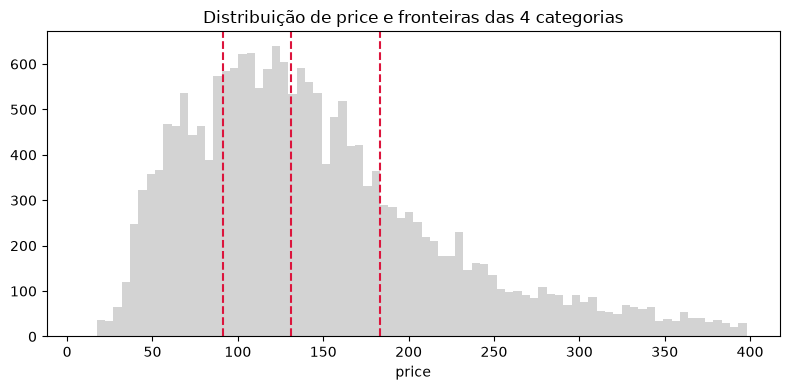

In [3]:
from logistic_regression import (run_classification_experiment, calcular_limites_quartis,
                                 categorizar_preco, CLASS_NAMES)

df_cls, feature_cols_cls, scale_cols_cls = carregar_estrategia("filter")

# Variável target categórica (visualização sobre o dataset todo; o treino recalcula
# os quartis só com as linhas de treino)
limites_todos = calcular_limites_quartis(df_cls["price"])
df_cls["price_cat"] = categorizar_preco(df_cls["price"], limites_todos)
print("Limites (Q1, Q2, Q3):", limites_todos)
print(df_cls["price_cat"].map(dict(enumerate(CLASS_NAMES))).value_counts().reindex(CLASS_NAMES))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_cls["price"], bins=80, color="lightgray")
for q in limites_todos:
    ax.axvline(q, color="crimson", linestyle="--")
ax.set_title("Distribuição de price e fronteiras das 4 categorias")
ax.set_xlabel("price")
plt.tight_layout()
plt.show()

In [4]:
resultados_cls = {}
linhas_cls = []
for degree in [1, 2, 3]:
    r = run_classification_experiment(
        df_cls, feature_cols_cls, price_col="price", degree=degree,
        scale_cols=scale_cols_cls, test_size=0.15, val_size=0.15,
        learning_rate=0.1, n_epochs=1000, l2_lambda=0.0, plot=False,
    )
    resultados_cls[degree] = r
    linha = {"degree": degree, "n_features_final": r["n_features_final"]}
    for split in ("train", "val", "test"):
        for metrica in ("accuracy", "macro_f1", "accuracy_pm1"):
            linha[f"{metrica}_{split}"] = r["metrics"][split][metrica]
    linhas_cls.append(linha)

df_resultados_cls = pd.DataFrame(linhas_cls)
df_resultados_cls.to_csv("logistic_results.csv", index=False)
print("Limites usados no treino (Q1, Q2, Q3):", resultados_cls[1]["limites"])
print("Baseline (prever sempre a mesma classe): accuracy ≈ 0.25")
df_resultados_cls.round(4)

Limites usados no treino (Q1, Q2, Q3): [ 90.5 131.  183. ]
Baseline (prever sempre a mesma classe): accuracy ≈ 0.25


,degree,n_features_final,accuracy_train,macro_f1_train,accuracy_pm1_train,accuracy_val,macro_f1_val,accuracy_pm1_val,accuracy_test,macro_f1_test,accuracy_pm1_test
0,1,51,0.5589,0.5566,0.9013,0.5553,0.5571,0.9043,0.5512,0.5494,0.8965
1,2,304,0.5844,0.5812,0.9089,0.5597,0.5591,0.9087,0.5661,0.5626,0.9127
2,3,2328,0.4156,0.3686,0.7464,0.4153,0.3726,0.7579,0.3984,0.3506,0.7345


Melhor grau (macro F1 val): 2
Teste: accuracy=0.5661  macro F1=0.5626  accuracy ±1 classe=0.9127


,precision,recall,f1
barato,0.7321,0.7699,0.7505
medio-barato,0.4748,0.5266,0.4994
medio-caro,0.4086,0.3320,0.3663
caro,0.6258,0.6426,0.6341


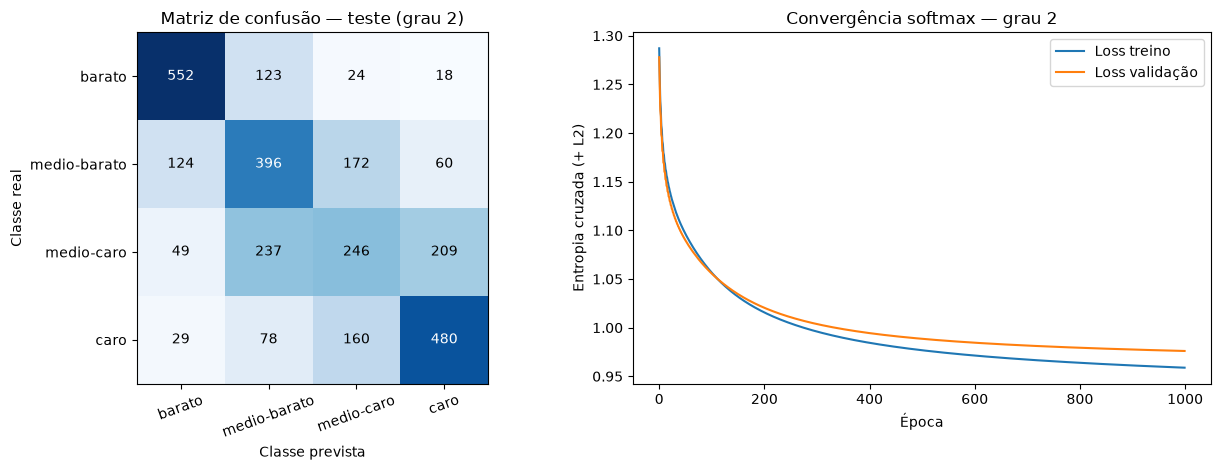

In [5]:
# Melhor grau escolhido pela macro F1 de VALIDAÇÃO; avaliação final no teste
melhor_grau = int(df_resultados_cls.loc[df_resultados_cls["macro_f1_val"].idxmax(), "degree"])
melhor = resultados_cls[melhor_grau]
m_test = melhor["metrics"]["test"]
print(f"Melhor grau (macro F1 val): {melhor_grau}")
print(f"Teste: accuracy={m_test['accuracy']:.4f}  macro F1={m_test['macro_f1']:.4f}  "
      f"accuracy ±1 classe={m_test['accuracy_pm1']:.4f}")

display(pd.DataFrame({"precision": m_test["precision"], "recall": m_test["recall"],
                      "f1": m_test["f1"]}, index=CLASS_NAMES).round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
cm = m_test["confusion_matrix"]
im = axes[0].imshow(cm, cmap="Blues")
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        axes[0].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
axes[0].set_xticks(range(4), CLASS_NAMES, rotation=20)
axes[0].set_yticks(range(4), CLASS_NAMES)
axes[0].set_xlabel("Classe prevista")
axes[0].set_ylabel("Classe real")
axes[0].set_title(f"Matriz de confusão — teste (grau {melhor_grau})")
melhor["model"].plot_convergence(title=f"Convergência softmax — grau {melhor_grau}", ax=axes[1])
plt.tight_layout()
plt.show()

### 14.2 Avaliação detalhada — Matriz de Confusão, ROC/AUC e outras métricas

Todas as métricas estão implementadas em `src/logistic_regression.py` (só numpy):

| Métrica | O que mede |
|---|---|
| **Accuracy** | % de previsões na classe certa |
| **Balanced accuracy** | média do recall das 4 classes (= accuracy aqui, porque as classes são equilibradas) |
| **Macro precision / recall / F1** | média simples por classe — cada classe pesa o mesmo |
| **Accuracy ±1** | % de previsões na classe certa ou numa vizinha (as classes são ordinais) |
| **MAE em classes** | distância média entre classe real e prevista (0 = perfeito, 3 = máximo) |
| **Kappa quadrático** | concordância acima do acaso, penalizando erros pelo quadrado da distância entre classes (0 = acaso, 1 = perfeito) |
| **AUC-ROC (one-vs-rest)** | por classe: probabilidade de o modelo dar mais score a um exemplo dessa classe do que a um de outra (0.5 = acaso, 1 = perfeito). *Macro* = média das 4 classes; *micro* = todas as decisões classe×linha juntas |
| **Average precision (AP)** | área sob a curva precision-recall de cada classe (acaso = 0.25) |
| **Log loss** | entropia cruzada das probabilidades — penaliza previsões confiantes e erradas (acaso uniforme = ln 4 ≈ 1.386) |

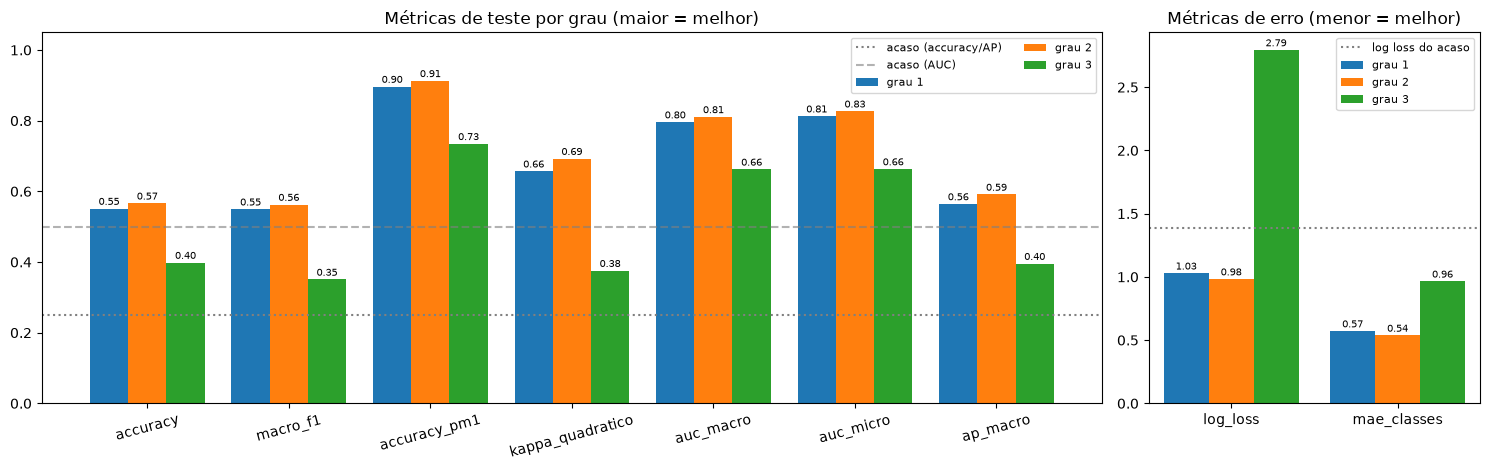

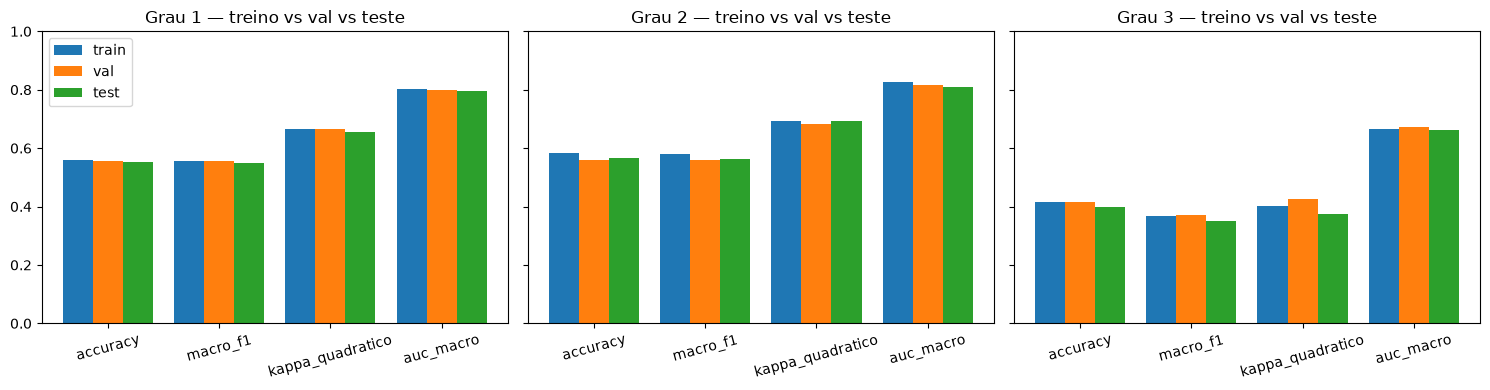

split      test                                                          \
       accuracy balanced_accuracy macro_precision macro_recall macro_f1   
degree                                                                    
1        0.5512            0.5528          0.5485       0.5528   0.5494   
2        0.5661            0.5678          0.5603       0.5678   0.5626   
3        0.3984            0.4004          0.3850       0.4004   0.3506   

split                                                                          \
       accuracy_pm1 mae_classes kappa_quadratico auc_macro auc_micro ap_macro   
degree                                                                          
1            0.8965      0.5715           0.6569    0.7959    0.8127   0.5642   
2            0.9127      0.5370           0.6924    0.8107    0.8266   0.5912   
3            0.7345      0.9648           0.3754    0.6622    0.6631   0.3953   

split            
       log_loss  
degree           
1        1.0284  
2        0.9824  
3        2.7939

In [6]:
from logistic_regression import roc_curve, precision_recall_curve

METRICAS_ESCALARES = ["accuracy", "balanced_accuracy", "macro_precision", "macro_recall",
                      "macro_f1", "accuracy_pm1", "mae_classes", "kappa_quadratico",
                      "auc_macro", "auc_micro", "ap_macro", "log_loss"]

tabela_metricas_cls = pd.DataFrame([
    {"degree": g, "split": split, **{m: r["metrics"][split][m] for m in METRICAS_ESCALARES}}
    for g, r in resultados_cls.items() for split in ("train", "val", "test")
])
tabela_metricas_cls.to_csv("logistic_results_detalhado.csv", index=False)

# --- Gráfico 1: métricas de teste por grau ---
teste = tabela_metricas_cls[tabela_metricas_cls["split"] == "test"].set_index("degree")
metricas_maior_melhor = ["accuracy", "macro_f1", "accuracy_pm1", "kappa_quadratico",
                         "auc_macro", "auc_micro", "ap_macro"]
cores_grau = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [3.2, 1]})
largura = 0.27
x = np.arange(len(metricas_maior_melhor))
for k, g in enumerate(teste.index):
    barras = axes[0].bar(x + (k - 1) * largura, teste.loc[g, metricas_maior_melhor], largura,
                         label=f"grau {g}", color=cores_grau[g])
    axes[0].bar_label(barras, fmt="%.2f", fontsize=7, padding=1)
axes[0].axhline(0.25, color="gray", linestyle=":", label="acaso (accuracy/AP)")
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.6, label="acaso (AUC)")
axes[0].set_xticks(x, metricas_maior_melhor, rotation=15)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Métricas de teste por grau (maior = melhor)")
axes[0].legend(fontsize=8, ncol=2)

for k, g in enumerate(teste.index):
    barras = axes[1].bar(np.arange(2) + (k - 1) * largura, teste.loc[g, ["log_loss", "mae_classes"]],
                         largura, label=f"grau {g}", color=cores_grau[g])
    axes[1].bar_label(barras, fmt="%.2f", fontsize=7, padding=1)
axes[1].axhline(np.log(4), color="gray", linestyle=":", label="log loss do acaso")
axes[1].set_xticks(range(2), ["log_loss", "mae_classes"])
axes[1].set_title("Métricas de erro (menor = melhor)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- Gráfico 2: treino vs validação vs teste (deteção de overfitting) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
metricas_split = ["accuracy", "macro_f1", "kappa_quadratico", "auc_macro"]
for ax, g in zip(axes, resultados_cls):
    t = tabela_metricas_cls[tabela_metricas_cls["degree"] == g].set_index("split")
    for k, split in enumerate(["train", "val", "test"]):
        ax.bar(np.arange(len(metricas_split)) + (k - 1) * largura, t.loc[split, metricas_split],
               largura, label=split)
    ax.set_xticks(range(len(metricas_split)), metricas_split, rotation=15)
    ax.set_title(f"Grau {g} — treino vs val vs teste")
    ax.set_ylim(0, 1)
axes[0].legend()
plt.tight_layout()
plt.show()

tabela_metricas_cls.pivot(index="degree", columns="split", values=METRICAS_ESCALARES) \
    .swaplevel(axis=1)[["test"]].round(4)

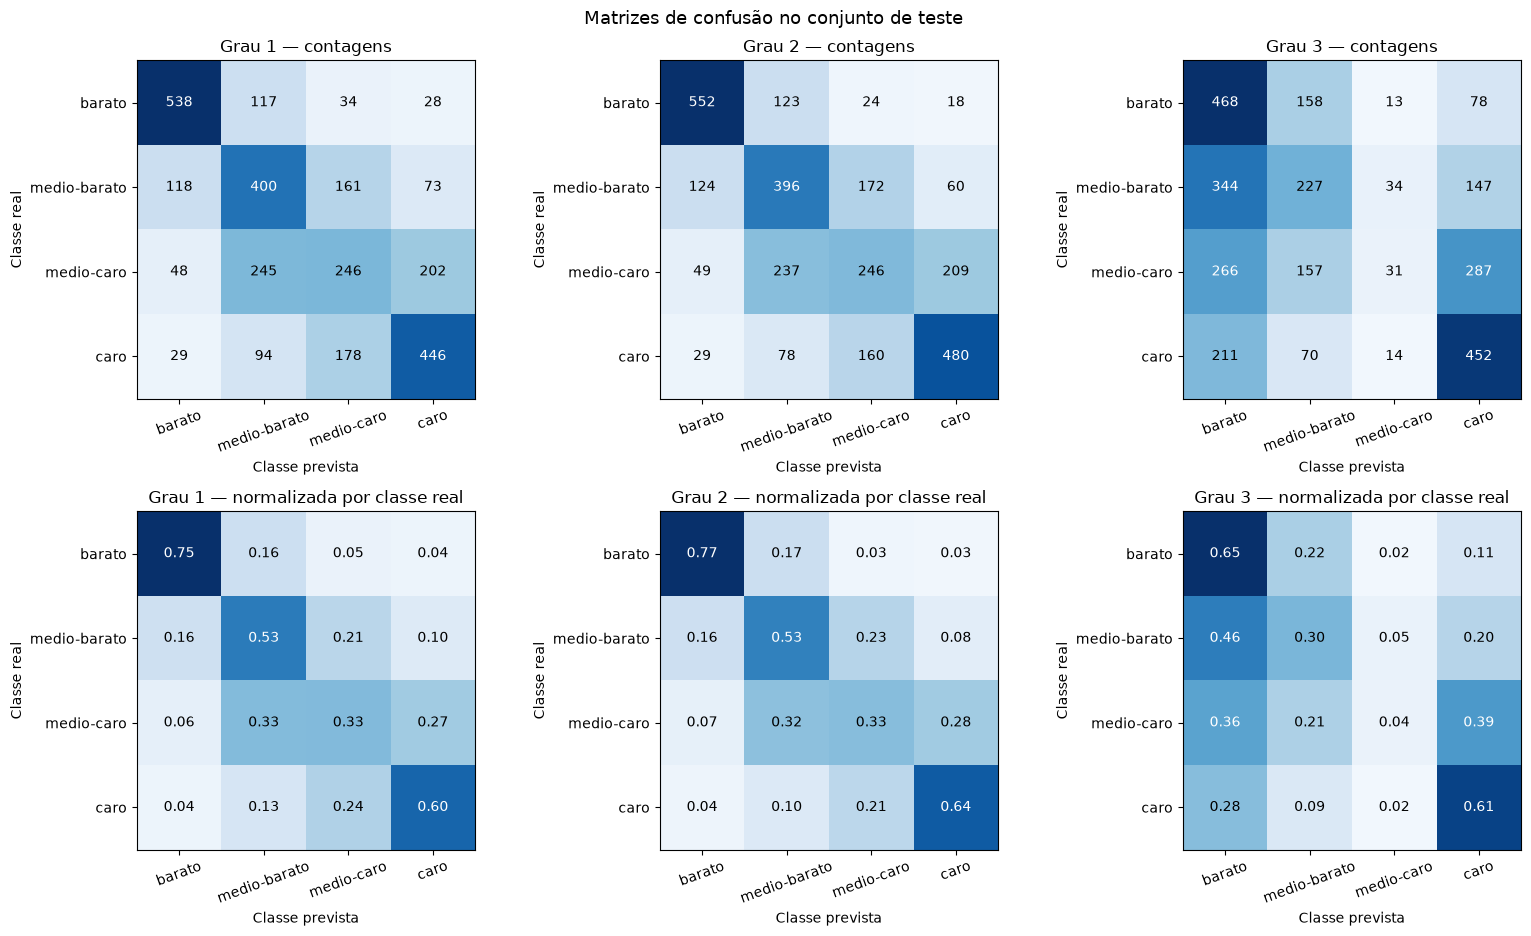

In [7]:
# --- Matrizes de confusão (teste): contagens e normalizadas por linha (= recall) ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
for col, (g, r) in enumerate(resultados_cls.items()):
    cm = r["metrics"]["test"]["confusion_matrix"]
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    for row, (mat, fmt, titulo) in enumerate([(cm, "d", "contagens"),
                                              (cm_norm, ".2f", "normalizada por classe real")]):
        ax = axes[row, col]
        ax.imshow(mat, cmap="Blues", vmin=0)
        for i in range(4):
            for j in range(4):
                ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                        color="white" if mat[i, j] > mat.max() / 2 else "black")
        ax.set_xticks(range(4), CLASS_NAMES, rotation=20)
        ax.set_yticks(range(4), CLASS_NAMES)
        ax.set_xlabel("Classe prevista")
        ax.set_ylabel("Classe real")
        ax.set_title(f"Grau {g} — {titulo}")
plt.suptitle("Matrizes de confusão no conjunto de teste", fontsize=13)
plt.tight_layout()
plt.show()

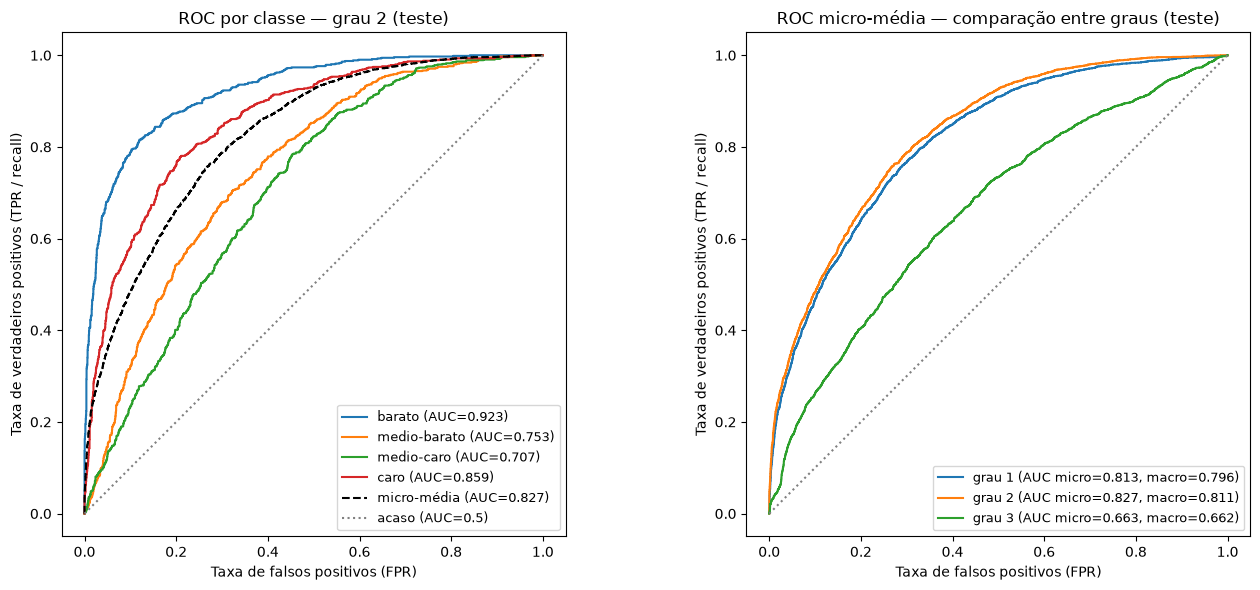

In [8]:
# --- Curvas ROC (one-vs-rest) no teste ---
y_test_cls = melhor["y_true"]["test"]
proba_test_cls = melhor["proba"]["test"]
Y_test_cls = np.eye(4)[y_test_cls]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for k, nome in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(Y_test_cls[:, k], proba_test_cls[:, k])
    axes[0].plot(fpr, tpr, label=f"{nome} (AUC={m_test['auc'][k]:.3f})")
fpr_mi, tpr_mi, _ = roc_curve(Y_test_cls.ravel(), proba_test_cls.ravel())
axes[0].plot(fpr_mi, tpr_mi, color="black", linestyle="--",
             label=f"micro-média (AUC={m_test['auc_micro']:.3f})")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle=":", label="acaso (AUC=0.5)")
axes[0].set_title(f"ROC por classe — grau {melhor_grau} (teste)")

# Comparação entre graus: ROC micro-média
for g, r in resultados_cls.items():
    Yg = np.eye(4)[r["y_true"]["test"]]
    fpr, tpr, _ = roc_curve(Yg.ravel(), r["proba"]["test"].ravel())
    axes[1].plot(fpr, tpr, color=cores_grau[g],
                 label=f"grau {g} (AUC micro={r['metrics']['test']['auc_micro']:.3f}, "
                       f"macro={r['metrics']['test']['auc_macro']:.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle=":")
axes[1].set_title("ROC micro-média — comparação entre graus (teste)")

for ax in axes:
    ax.set_xlabel("Taxa de falsos positivos (FPR)")
    ax.set_ylabel("Taxa de verdadeiros positivos (TPR / recall)")
    ax.set_aspect("equal")
    ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

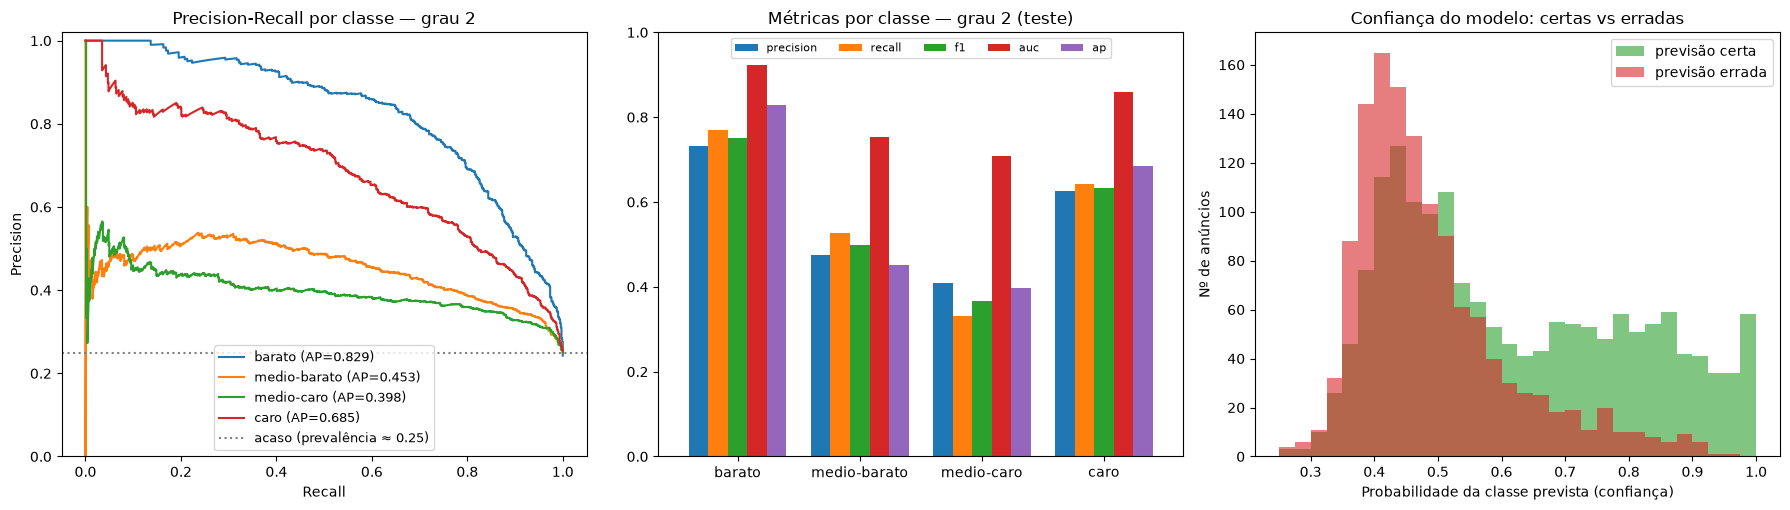

,n,accuracy
faixa_confianca,,
"(0.25, 0.4]",449,0.365
"(0.4, 0.5]",994,0.447
"(0.5, 0.6]",543,0.543
"(0.6, 0.7]",284,0.651
"(0.7, 0.8]",273,0.780
"(0.8, 1.0]",414,0.901


,precision,recall,f1,auc,ap
barato,0.7321,0.7699,0.7505,0.9235,0.8294
medio-barato,0.4748,0.5266,0.4994,0.7528,0.4526
medio-caro,0.4086,0.3320,0.3663,0.7074,0.3980
caro,0.6258,0.6426,0.6341,0.8590,0.6847


In [9]:
# --- Curvas precision-recall, métricas por classe e confiança das previsões ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

for k, nome in enumerate(CLASS_NAMES):
    precision, recall = precision_recall_curve(Y_test_cls[:, k], proba_test_cls[:, k])
    axes[0].plot(recall, precision, label=f"{nome} (AP={m_test['ap'][k]:.3f})")
axes[0].axhline(0.25, color="gray", linestyle=":", label="acaso (prevalência ≈ 0.25)")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_ylim(0, 1.02)
axes[0].set_title(f"Precision-Recall por classe — grau {melhor_grau}")
axes[0].legend(fontsize=9)

por_classe = pd.DataFrame({"precision": m_test["precision"], "recall": m_test["recall"],
                           "f1": m_test["f1"], "auc": m_test["auc"], "ap": m_test["ap"]},
                          index=CLASS_NAMES)
por_classe.plot.bar(ax=axes[1], rot=0, width=0.8)
axes[1].set_ylim(0, 1)
axes[1].set_title(f"Métricas por classe — grau {melhor_grau} (teste)")
axes[1].legend(fontsize=8, ncol=5, loc="upper center")

confianca = proba_test_cls.max(axis=1)
acertou = proba_test_cls.argmax(axis=1) == y_test_cls
bins = np.linspace(0.25, 1, 31)
axes[2].hist(confianca[acertou], bins=bins, alpha=0.6, color="tab:green", label="previsão certa")
axes[2].hist(confianca[~acertou], bins=bins, alpha=0.6, color="tab:red", label="previsão errada")
axes[2].set_xlabel("Probabilidade da classe prevista (confiança)")
axes[2].set_ylabel("Nº de anúncios")
axes[2].set_title("Confiança do modelo: certas vs erradas")
axes[2].legend()
plt.tight_layout()
plt.show()

# Accuracy por faixa de confiança: se o modelo estiver bem calibrado, sobe com a confiança
faixas = pd.cut(confianca, [0.25, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0])
display(pd.DataFrame({"faixa_confianca": faixas, "acertou": acertou})
        .groupby("faixa_confianca", observed=True)["acertou"].agg(n="size", accuracy="mean").round(3))
por_classe.round(4)

### 14.3 Conclusões — classificação

| Grau | Features | Accuracy teste | Macro F1 teste | Accuracy ±1 classe |
|---|---|---|---|---|
| 1 | 51 | 0.551 | 0.549 | 0.897 |
| **2** | 304 | **0.566** | **0.563** | **0.913** |
| 3 | 2328 | 0.398 | 0.351 | 0.735 |

- **O modelo aprende bastante**: ~56% de accuracy contra 25% do baseline (4 classes equilibradas), e **91% das previsões ficam na classe certa ou numa vizinha** — erros grosseiros (barato ↔ caro) são raros.
- **Melhor grau = 2** (escolhido pela macro F1 de validação), em linha com a regressão: as interações de 2.ª ordem ajudam ligeiramente. O grau 3 piora muito — com 2328 features e `learning_rate=0.1`, o gradient descent oscila e não converge em 1000 épocas (é um problema de otimização, não de capacidade do modelo).
- **As classes extremas são fáceis, as do meio difíceis**: F1 de `barato` 0.75 e `caro` 0.63, contra `medio-barato` 0.50 e `medio-caro` 0.37. As fronteiras Q1–Q2–Q3 estão próximas (91 → 131 → 183 €): um anúncio de 130 € e um de 135 € são quase iguais nas features mas caem em classes diferentes.
- **Comparação com a regressão**: um MAE de ~41–42 € (secção 8, filter) já é comparável à largura das classes do meio (~40–50 €), o que explica por que razão a classificação exata dessas classes é difícil. Para uso prático ("este anúncio é barato ou caro?") a classificação é mais fácil de interpretar e acerta quase sempre a "zona" de preço.
- **Métricas da secção 14.2 (teste, grau 2)**: AUC macro **0.811** / micro 0.827, kappa quadrático **0.69** (concordância substancial, tendo em conta que as classes são ordenadas), MAE em classes 0.54, log loss 0.98 (contra 1.386 do acaso). O grau 3 é pior em todas as métricas, e a sua log loss (2.79) é **pior que o acaso** — dá probabilidades muito confiantes e erradas, sintoma de que o treino não convergiu.
- **ROC/AUC por classe**: `barato` AUC 0.92 e `caro` 0.86 separam-se bem; `medio-barato` 0.75 e `medio-caro` 0.71 estão bem acima do acaso, mas as curvas precision-recall mostram que a precisão destas duas classes fica nos 0.40–0.50 para quase todo o recall.
- **Matriz de confusão**: quase todos os erros estão na diagonal vizinha. O padrão mais notório é `medio-caro`, que o modelo confunde com `medio-barato` e com `caro` (recall só 0.33) — é "espremida" pelas classes dos lados.
- **As probabilidades são informativas (calibração razoável)**: a accuracy sobe de forma monótona com a confiança do modelo — 37% quando a probabilidade máxima é ≤0.4, 90% quando é >0.8. Na prática, as previsões com confiança > 0.7 (~25% do teste) são fiáveis; as restantes deviam ser lidas como "uma de duas classes vizinhas".


## 15. Representações Latentes do Texto com um LLM (embeddings 256 / 512 / 1024)

Até aqui o modelo só usou variáveis estruturadas. Nesta secção partimos do **dataset cru** (`data/listings.csv`) e usamos **só o texto** de cada anúncio para prever o preço.

**1. Texto usado.** Todas as colunas de texto (não numéricas), exceto as realmente inúteis ou proibidas. A seleção é automática em `src/llm_embeddings.py`:

| Excluídas | Motivo |
|---|---|
| `listing_url`, `picture_url`, `host_url`, `host_profile_url`, `host_picture_url` | links |
| `host_name`, `license` | identificação |
| `last_scraped`, `calendar_last_scraped`, `source` | metadados do scraping |
| `price`, `price_quote_raw`, `price_quote_checkin_date`, `price_quote_checkout_date` | o target e cotações de preço → **leakage** |

Ficam 16 colunas (nome, descrição, tipo de propriedade/quarto, bairro, casas de banho, amenities, flags do anfitrião, datas das reviews, localização e "about" do anfitrião). Cada anúncio vira um texto `Campo: valor` por linha (HTML limpo, `t/f` → `yes/no`, lista de amenities em texto corrido).

**2. LLM.** [`Qwen/Qwen3-Embedding-0.6B`](https://huggingface.co/Qwen/Qwen3-Embedding-0.6B) — um LLM pequeno (0.6 mil milhões de parâmetros) treinado para gerar embeddings, a correr na GPU em float16 (`max_seq_length=512` tokens). Gera vetores de 1024 dimensões e foi treinado com *Matryoshka Representation Learning*: as primeiras 256 ou 512 componentes também são um embedding válido. Assim, os 3 CSVs vêm do **mesmo** modelo (truncado e renormalizado), e a única diferença entre eles é a dimensão.

**3. Regressão.** `LinearRegressionGD` (o mesmo gradient descent das secções anteriores), split 70/15/15 com `random_state=42`, sem L2, `n_epochs=1000`, `learning_rate=0.005` (0.001 fica longe da convergência em 1000 épocas; 0.01 faz divergir a versão quadrática de 1024 dims):
- **linear**: as `d` componentes do embedding;
- **quadrática**: cada componente e o seu quadrado (`x_i`, `x_i²` → `2d` features). Os termos cruzados `x_i·x_j` são impraticáveis aqui: com `PolynomialFeatures(2)` seriam 33 mil features para d=256, 131 mil para d=512 e 525 mil para d=1024 (a matriz de treino de 1024 ocuparia ~60 GB).

Dois tratamentos do target: `none` (preço cru) e `filter` (remove os outliers de `price` com o mesmo critério MAD da secção 6).

In [3]:
from llm_embeddings import (gerar_csvs_embeddings, carregar_embeddings, adicionar_quadrados,
                            caminho_csv, DIMENSOES, COLS_TEXTO_EXCLUIDAS)

emb_dir = Path("Data_clean/embeddings")
REGENERAR_EMBEDDINGS = False  # True -> volta a passar o texto pelo LLM (~15 min numa RTX 3060)

if REGENERAR_EMBEDDINGS or not all(caminho_csv(emb_dir, d).exists() for d in DIMENSOES):
    gerar_csvs_embeddings("data/listings.csv", outdir=emb_dir)
else:
    print("CSVs de embeddings já existem — a reutilizar (REGENERAR_EMBEDDINGS=False).")

for d in DIMENSOES:
    caminho = caminho_csv(emb_dir, d)
    print(f"  {caminho}  ({caminho.stat().st_size / 1e6:.0f} MB)")

df_texto = pd.read_csv(emb_dir / "listings_texto.csv")
print(f"\n{len(df_texto)} anúncios | comprimento do texto: mediana "
      f"{df_texto['texto'].str.len().median():.0f} caracteres")
print("\n--- Exemplo de texto enviado ao LLM ---")
print(df_texto["texto"].iloc[0][:1200], "...")

CSVs de embeddings já existem — a reutilizar (REGENERAR_EMBEDDINGS=False).
  Data_clean/embeddings/listings_emb_256.csv  (61 MB)
  Data_clean/embeddings/listings_emb_512.csv  (122 MB)
  Data_clean/embeddings/listings_emb_1024.csv  (243 MB)



24876 anúncios | comprimento do texto: mediana 1414 caracteres

--- Exemplo de texto enviado ao LLM ---
Name: Belém 1 Bedroom Historical Apartment
Property type: Entire rental unit
Room type: Entire home/apt
Neighbourhood group cleansed: Lisboa
Neighbourhood cleansed: Belm
Bathrooms text: 1 bath
Description: This apartment is all about Location, next to the National Coach Museum and the Portuguese President Official Residence.
 Belém is a premium location where Lisbon major monuments are located. All are walking distance, as well as the river facing the apartment.
Although the building is old as most in the area but we did our best upgrading it.
If you are looking for a budget option in one of the best areas in Town, you have found it.
Public transportation is by the door, both buses and the 15 Tram
Amenities: Toaster, Shower gel, Fire extinguisher, Oven, Free street parking, Bed linens, Wifi, Kitchen, Hangers, Hot water kettle, Coffee maker, Dishes and silverware, Ethernet connection

In [4]:
from linear_regression import run_experiment

EMB_CONFIG = dict(test_size=0.15, val_size=0.15, learning_rate=0.005,
                  n_epochs=1000, l2_lambda=0.0, verbose=False, plot=False)

resultados_emb = []
for dim in DIMENSOES:
    df_emb, emb_cols = carregar_embeddings(dim, outdir=emb_dir)
    df_emb = df_emb.dropna(subset=["price"]).reset_index(drop=True)

    for tratamento in ["none", "filter"]:
        if tratamento == "filter":
            mask_out, _, _ = detect_outliers_mad(df_emb["price"])  # mesmo critério da secção 6
            df_t = df_emb.loc[~mask_out].reset_index(drop=True)
        else:
            df_t = df_emb

        for tipo in ["linear", "quadratica"]:
            df_x, cols_x = adicionar_quadrados(df_t, emb_cols) if tipo == "quadratica" else (df_t, emb_cols)
            r = run_experiment(df_x, cols_x, target_col, degree=1, scale_cols=cols_x, **EMB_CONFIG)
            linha = {"dim": dim, "tratamento": tratamento, "tipo": tipo,
                     "n_linhas": len(df_t), "n_features": r["n_features_final"],
                     "diverged": r["model"].diverged_}
            for split in ("train", "val", "test"):
                for metrica, valor in r["metrics"][split].items():
                    linha[f"{metrica}_{split}"] = valor
            resultados_emb.append(linha)
            print(f"[dim={dim:4d} {tratamento:6s} {tipo:10s}] features={r['n_features_final']:4d}  "
                  f"R2 treino={linha['r2_train']:.4f}  R2 val={linha['r2_val']:.4f}  "
                  f"R2 teste={linha['r2_test']:.4f}  MAE teste={linha['mae_test']:.2f}")

df_resultados_emb = pd.DataFrame(resultados_emb)
df_resultados_emb.to_csv("gd_results_embeddings.csv", index=False)

[dim= 256 none   linear    ] features= 256  R2 treino=0.1601  R2 val=0.1793  R2 teste=0.1362  MAE teste=119.64


[dim= 256 none   quadratica] features= 512  R2 treino=0.2129  R2 val=0.2553  R2 teste=0.1914  MAE teste=126.36


[dim= 256 filter linear    ] features= 256  R2 treino=0.4401  R2 val=0.4095  R2 teste=0.4015  MAE teste=44.84


[dim= 256 filter quadratica] features= 512  R2 treino=0.4625  R2 val=0.4167  R2 teste=0.4117  MAE teste=44.53


[dim= 512 none   linear    ] features= 512  R2 treino=0.2183  R2 val=0.2647  R2 teste=0.2188  MAE teste=124.30


...

[dim= 512 filter quadratica] features=1024  R2 treino=0.5209  R2 val=0.4684  R2 teste=0.4442  MAE teste=42.93


[dim=1024 none   linear    ] features=1024  R2 treino=0.2875  R2 val=0.3498  R2 teste=0.2990  MAE teste=130.17


[dim=1024 none   quadratica] features=2048  R2 treino=0.4148  R2 val=0.4992  R2 teste=0.4027  MAE teste=144.34


[dim=1024 filter linear    ] features=1024  R2 treino=0.5302  R2 val=0.4713  R2 teste=0.4604  MAE teste=42.04


[dim=1024 filter quadratica] features=2048  R2 treino=0.5851  R2 val=0.4789  R2 teste=0.4565  MAE teste=42.19


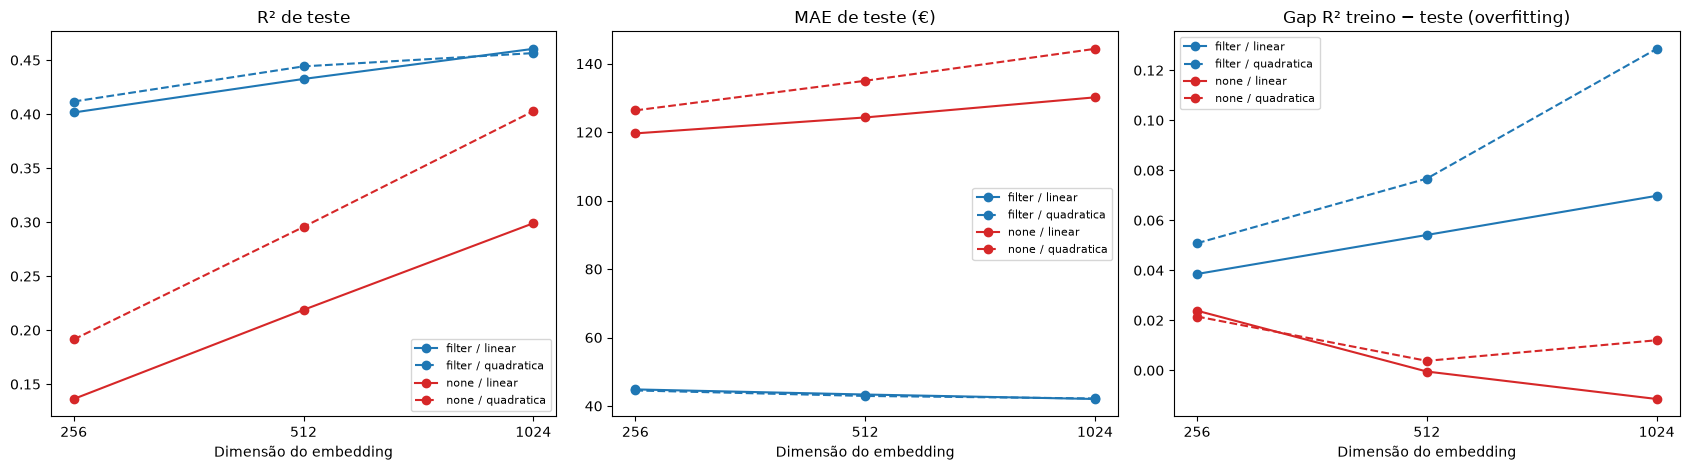

,dim,tratamento,tipo,n_features,r2_train,r2_val,r2_test,mae_test,rmse_test
0,256,filter,linear,256,0.4401,0.4095,0.4015,44.8396,59.3010
1,512,filter,linear,512,0.4867,0.4571,0.4326,43.3463,57.7428
2,1024,filter,linear,1024,0.5302,0.4713,0.4604,42.0387,56.3060
3,256,filter,quadratica,512,0.4625,0.4167,0.4117,44.5316,58.7964
4,512,filter,quadratica,1024,0.5209,0.4684,0.4442,42.9254,57.1464
5,1024,filter,quadratica,2048,0.5851,0.4789,0.4565,42.1937,56.5110
6,256,none,linear,256,0.1601,0.1793,0.1362,119.6370,421.5764
7,512,none,linear,512,0.2183,0.2647,0.2188,124.2953,400.9339
8,1024,none,linear,1024,0.2875,0.3498,0.2990,130.1688,379.7977
9,256,none,quadratica,512,0.2129,0.2553,0.1914,126.3565,407.9074


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
estilos = {("filter", "linear"): ("tab:blue", "-"), ("filter", "quadratica"): ("tab:blue", "--"),
           ("none", "linear"): ("tab:red", "-"), ("none", "quadratica"): ("tab:red", "--")}
for (trat, tipo), t in df_resultados_emb.groupby(["tratamento", "tipo"]):
    cor, ls = estilos[(trat, tipo)]
    rotulo = f"{trat} / {tipo}"
    axes[0].plot(t["dim"], t["r2_test"], marker="o", color=cor, linestyle=ls, label=rotulo)
    axes[1].plot(t["dim"], t["mae_test"], marker="o", color=cor, linestyle=ls, label=rotulo)
    axes[2].plot(t["dim"], t["r2_train"] - t["r2_test"], marker="o", color=cor, linestyle=ls, label=rotulo)
axes[0].set_title("R² de teste")
axes[1].set_title("MAE de teste (€)")
axes[2].set_title("Gap R² treino − teste (overfitting)")
for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xticks(DIMENSOES, [str(d) for d in DIMENSOES])
    ax.set_xlabel("Dimensão do embedding")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

(df_resultados_emb[["dim", "tratamento", "tipo", "n_features", "r2_train", "r2_val",
                    "r2_test", "mae_test", "rmse_test"]]
 .sort_values(["tratamento", "tipo", "dim"]).round(4).reset_index(drop=True))

In [6]:
# Comparação com os modelos das variáveis estruturadas (secção 8, mesmo split 70/15/15)
tab = pd.read_csv("gd_results_single_split.csv")
tab = tab[tab["degree"].isin([1, 2])]
comparacao_emb = pd.concat([
    tab.assign(modelo="tabular (secção 8)",
               variante=tab["outlier_strategy"] + " / grau " + tab["degree"].astype(str))
       [["modelo", "variante", "n_features_final", "r2_test", "mae_test", "rmse_test"]]
       .rename(columns={"n_features_final": "n_features"}),
    df_resultados_emb.assign(modelo="texto (LLM)",
                             variante=df_resultados_emb["tratamento"] + " / " + df_resultados_emb["tipo"]
                                      + " / " + df_resultados_emb["dim"].astype(str))
       [["modelo", "variante", "n_features", "r2_test", "mae_test", "rmse_test"]],
], ignore_index=True)
comparacao_emb.sort_values("r2_test", ascending=False).round(4).reset_index(drop=True)

,modelo,variante,n_features,r2_test,mae_test,rmse_test
0,tabular (secção 8),cap / grau 2,321,0.5489,46.1123,63.6953
1,tabular (secção 8),cap / grau 1,45,0.4905,49.0569,67.6965
2,texto (LLM),filter / linear / 1024,1024,0.4604,42.0387,56.3060
3,texto (LLM),filter / quadratica / 1024,2048,0.4565,42.1937,56.5110
4,texto (LLM),filter / quadratica / 512,1024,0.4442,42.9254,57.1464
5,texto (LLM),filter / linear / 512,512,0.4326,43.3463,57.7428
6,tabular (secção 8),filter / grau 2,304,0.4138,42.4883,56.4971
7,texto (LLM),filter / quadratica / 256,512,0.4117,44.5316,58.7964
8,texto (LLM),none / quadratica / 1024,2048,0.4027,144.3406,350.5587
9,texto (LLM),filter / linear / 256,256,0.4015,44.8396,59.3010


### 15.1 Conclusões — texto via LLM

| Embedding | `filter` linear R² teste | `filter` quadrática R² teste | `filter` MAE teste |
|---|---|---|---|
| 256 | 0.402 | 0.412 | 44.8 € |
| 512 | 0.433 | 0.444 | 43.3 € |
| 1024 | **0.460** | 0.457 | **42.0 €** |

- **Só o texto já prevê bem o preço.** Com o outlier `filter` em `price`, o embedding de 1024 dims chega a **R² 0.46 e MAE 42 €**. Isto é melhor do que o modelo tabular `filter` de grau 1 (0.32) e de grau 2 (0.41), e fica só abaixo do tabular `cap` (0.49–0.55). O texto traz quase tudo o que as variáveis estruturadas têm (tipo de quarto, bairro, nº de casas de banho, amenities), e mais (qualidade da descrição, vista, luxo...).
- **Mais dimensões ajudam, mas com retornos decrescentes.** De 256 para 1024 o R² sobe +0.06 e o MAE desce ~3 €, mas o gap treino−teste também cresce (0.04 → 0.07 no linear, 0.05 → 0.13 no quadrático). Com 1024+ features e ~15 mil linhas de treino o modelo começa a decorar o treino; uma L2 a sério (λ na ordem das centenas, ver secção 13) seria o passo seguinte.
- **A versão quadrática quase não acrescenta nada com `filter`** (+0.01 em 256/512, empate em 1024), e o overfitting é maior. Os embeddings já são uma representação não-linear do texto, por isso a relação com o preço é aproximadamente linear nesse espaço.
- **Sem tratar outliers (`none`), o R² engana.** A quadrática de 1024 dims sobe até R² 0.40, mas o **MAE piora** (120 → 144 €) à medida que o R² sobe. O modelo ganha R² a aproximar-se dos poucos preços extremos e, para isso, piora a previsão do anúncio típico. Com `filter`, R² e MAE melhoram em conjunto, como seria de esperar.
- **Cuidado ao comparar com a secção 8.** Os conjuntos de linhas não são iguais: aqui usam-se todos os anúncios com preço do dataset cru, e o `filter` só filtra `price` (21 236 linhas). Na secção 8 há a limpeza de valores em falta e o `filter` também filtra `minimum_nights` e `accommodates` (19 717 linhas). A comparação dá uma ordem de grandeza, não um ranking exato.
- **Próximo passo natural:** juntar os embeddings às variáveis tabulares no mesmo modelo, ou reduzir o embedding com PCA antes da expansão quadrática com termos cruzados.
